# Comparative Analysis of Sequential Models for Mobile Network Traffic Forecasting

## 1. Title and research question

This notebook walks through the whole investigation I did into predicting mobile Internet traffic a short time ahead and it takes each step in the order I actually worked through them.

The research question is:

> How do different sequential models compare for one-step-ahead mobile network
> traffic forecasting, and how does their performance vary across geographical
> areas with different traffic characteristics?

The data comes from the Telecom Italia network in Milan [1], where activity is recorded once every 10 minutes for roughly two months, and the city itself is divided into a grid of 10,000 small areas.

I wanted to compare three different ways of using past traffic to predict the next ten minutes. I measured their accuracy and looked at the periods where their predictions were furthest from the actual traffic.

The three models are:

1. A Selected-Lag Autoregressive model, which is a linear formula built from a chosen set of past values, so every weight it learns can be read and checked by hand.
2. An LSTM, which is a neural network that keeps its own memory of the sequence and updates that memory as it reads each new value.
3. A Temporal Convolutional Network, which slides filters over the past values and is built so that it can never see anything after the point it is predicting.

I also measure three very simple forecasts that need no training at all. The models need something fair to be compared against. A model that cannot beat a simple forecast has not really earned its place.

**Most of the heavy work is not done in this notebook:** It is done by the Python scripts in `scripts/`. Those scripts download the 62 raw files, add up 319,896,289 rows of raw data, run every tuning experiment and train the three models. Together that takes several hours and needs the full 19.38 GiB of raw data on disk. A notebook is the wrong place for work like that, because anyone who opened it would have to sit through all of it again before seeing a single result.

**What this notebook does:** It reads the small files that those scripts already saved, which are the two processed data files and the result files in `results/`. From them it rebuilds the exploratory analysis, draws the figures, shows the final tables and explains what the numbers mean. That is why it runs in a few seconds, and the numbers you see here are exactly the ones the scripts produced.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, adfuller


def find_repository_root(start: Path) -> Path:
    """Search upwards for the folder that holds both data/ and results/."""
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise RuntimeError("repository root not found from %s" % start)


ROOT = find_repository_root(Path.cwd().resolve())
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"

TZ = "Europe/Rome"

# This plain figure style is used for every figure in this notebook.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
GRIDCOL = "#e5e4e0"
BLUE = "#2a78d6"
ORANGE = "#eb6834"


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRIDCOL)
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(colors=INK_2, labelsize=9, length=3, width=0.8)
    ax.grid(True, color=GRIDCOL, linewidth=0.6, linestyle="-")
    ax.set_axisbelow(True)


pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("repository root:", ROOT.name)
print("processed data :", PROC.relative_to(ROOT))
print("results        :", RESULTS.relative_to(ROOT))

repository root: mobile-network-traffic-forecasting-
processed data : data\processed
results        : results


## 2. Dataset and data understanding

### 2.1 Raw structure

Each raw daily file is split by tabs and holds eight fields, with no header row at the top. I therefore took the meaning of every column from the dataset documentation [1], rather than guessing at what they were.

| Position | Column | Meaning |
|---|---|---|
| 1 | square_id | Which of the 10,000 grid squares |
| 2 | time_interval | Start of a 10 minute slot, in milliseconds |
| 3 | country_code | Phone country code of the other party |
| 4 | sms_in | Received SMS activity |
| 5 | sms_out | Sent SMS activity |
| 6 | call_in | Received call activity |
| 7 | call_out | Outgoing call activity |
| 8 | internet | Internet traffic activity |

**The forecasting target is the `internet` column.** The other activity columns were not used for forecasting.

### 2.2 Two details that change the numbers

**Country codes:** The same square and timestamp can appear several times in a file, because there is one row for each country code. On 1 November there were 4,842,625 rows but only 1,439,982 different pairs of square and timestamp. I added the Internet activity of those country codes together, so that each square ends up with a single value for every 10 minute slot. Without that step, three or four rows would describe the same moment in time.

**Blank fields:** Missing values appear as empty text between two tabs. I handle two different cases in two different ways, and this is a choice I made and wrote down rather than something the data itself tells us:

- A blank `internet` field inside a row that does exist adds zero to the total for that slot because the row is there but nothing was recorded in it.
- A square and timestamp with no row at all stays marked as missing so that it is never quietly turned into a zero.

The second case never came up for the five areas studied here. All five had 8,928 of the 8,928 slots that were expected.

### 2.3 Example rows

The raw dataset is 19.38 GiB spread over 62 files, so it is never loaded inside this notebook. The cell below shows a few rows of the small processed series instead.

In [2]:
series = pd.read_csv(PROC / "selected_area_timeseries.csv")
series["datetime"] = pd.to_datetime(series["datetime"], utc=True).dt.tz_convert("Europe/Rome")

print("processed selected-area series:", series.shape)
display(series.head(5))

print("timestamps are 10 minutes apart, in Milan local time:")
sample = series[series.square_id == 5161].sort_values("timestamp").head(4)
for _, row in sample.iterrows():
    print("   %s   internet = %.3f" % (row["datetime"], row["internet_traffic"]))

processed selected-area series: (44640, 4)


,square_id,timestamp,datetime,internet_traffic
0,4159,1383260400000,2013-11-01 00:00:00+01:00,224.808532
1,4159,1383261000000,2013-11-01 00:10:00+01:00,183.504997
2,4159,1383261600000,2013-11-01 00:20:00+01:00,204.431304
3,4159,1383262200000,2013-11-01 00:30:00+01:00,212.374053
4,4159,1383262800000,2013-11-01 00:40:00+01:00,195.768007


timestamps are 10 minutes apart, in Milan local time:
   2013-11-01 00:00:00+01:00   internet = 379.973
   2013-11-01 00:10:00+01:00   internet = 371.123
   2013-11-01 00:20:00+01:00   internet = 429.298
   2013-11-01 00:30:00+01:00   internet = 350.184


## 3. Memory management

### 3.1 Why the normal approach did not work

The whole dataset takes 19.38 GiB on disk and holds 319,896,289 rows. A single daily file read with the normal pandas settings comes back as 8 columns of 64 bit types. Scaled up to all 62 files, that works out at roughly 18.5 GB in memory. My machine has only 15.65 GB of RAM, so loading everything at once was never going to work.

### 3.2 What was measured

I measured memory usage using the 1 November file, which contains 4,842,625 rows. The table below shows the measurements recorded during that test, so running this notebook displays those values rather than repeating the measurement. The measurement itself is reproducible. `scripts/memory_benchmark.py` performs the same four loads and prints the same table, and it needs the raw file:

```
python scripts/memory_benchmark.py
```

Two different quantities appear in this section, and they should not be mixed up. The table below reports the memory held by the dataframe itself, measured with `memory_usage(deep=True)` and divided by 1,048,576, so the unit is mebibytes. The 91.4 MiB quoted later is the peak working set of the whole Python process, which `scripts/prepare_data.py` reports for the totals phase. The second number includes the interpreter, pandas and NumPy, so it is larger than any single dataframe.

In [3]:
memory_benchmark = pd.DataFrame([
    {"approach": "Full 8-column load, default dtypes",
     "columns": 8, "memory_MiB": 295.57},
    {"approach": "3 columns, reduced dtypes",
     "columns": 3, "memory_MiB": 64.66},
    {"approach": "2 columns used for aggregation",
     "columns": 2, "memory_MiB": 27.71},
    {"approach": "One chunk of 500,000 rows",
     "columns": 2, "memory_MiB": 2.86},
])
baseline = memory_benchmark.loc[0, "memory_MiB"]
memory_benchmark["reduction_vs_baseline_%"] = (
    100 * (baseline - memory_benchmark["memory_MiB"]) / baseline).round(2)
display(memory_benchmark)

,approach,columns,memory_MiB,reduction_vs_baseline_%
0,"Full 8-column load, default dtypes",8,295.57,0.00
1,"3 columns, reduced dtypes",3,64.66,78.12
2,2 columns used for aggregation,2,27.71,90.62
3,"One chunk of 500,000 rows",2,2.86,99.03


### 3.3 Data type decisions

I checked every type against the range of values that actually appear in the data before using it. One of the choices that looked obvious at first turned out to be unsafe.

| Column | Type used | Why it is safe |
|---|---|---|
| square_id | int16 | Values run 1 to 10000, well inside the int16 limit of 32767 |
| time_interval | int64 | Values are about 1.38e12. **int32 cannot safely represent timestamp values around 1.38e12, so int64 is required** (int32 stops at 2,147,483,647) |
| internet | float32 for storage | Maximum around 5e3, and float32 keeps about 7 significant digits |
| running totals | float64 | See below |

Storing the Internet values as float32 costs a relative error of about 6e-08 on each value, which is far too small to matter. Adding millions of float32 values together in float32 is a different story, because on a single day that lost about 1.4 in absolute terms. Every running total is therefore added up in float64, while the values themselves stay stored as float32.

### 3.4 The processing strategy

The files are handled one at a time. Each one is read in chunks of 500,000 rows:

```
one raw file -> read only the needed columns, in chunks
             -> aggregate the chunk
             -> add into a small running total
             -> release the chunk
             -> next file
```

The only thing carried from one file to the next is a float64 accumulator with 10,001 slots, which takes about 80 KB. The memory used at the peak therefore stays the same, no matter how many files have already been read.

In [4]:
outcome = pd.DataFrame([
    {"measurement": "Raw rows scanned", "value": "319,896,289"},
    {"measurement": "Raw data on disk", "value": "19.38 GiB"},
    {"measurement": "Chunk size", "value": "500,000 rows"},
    {"measurement": "Peak memory of one chunk", "value": "2.86 MiB"},
    {"measurement": "Peak working set of the aggregation process", "value": "91.4 MiB"},
    {"measurement": "Totals pass processing time", "value": "156.4 s"},
])
display(outcome)

,measurement,value
0,Raw rows scanned,"319,896,289"
1,Raw data on disk,19.38 GiB
2,Chunk size,"500,000 rows"
3,Peak memory of one chunk,2.86 MiB
4,Peak working set of the aggregation process,91.4 MiB
5,Totals pass processing time,156.4 s


The table above covers the totals pass, which is the run that produced the traffic total of every square. It read the whole 19.38 GiB dataset in 156.4 seconds inside about 91 MiB of RAM. The series pass that follows it is a second run over the same files, so the 9 minutes quoted in the README covers both. The aggregation itself is **not** run again inside this notebook, because it takes about two and a half minutes and needs the raw files to be present. The command that produced the result used below is:

```
python scripts/prepare_data.py --phase totals
```

Its output `data/processed/total_traffic_by_square.csv` is the file that the next section reads.

## 4. Exploratory analysis

Before picking any model I wanted to understand how this traffic behaves. The three parts below look at the data from three different angles: how traffic is spread over the whole city, which areas carry most of it, and how a single area changes from hour to hour and between weekdays and weekends. Each of these views shapes a modelling decision later on, so none of these plots are here to fill space.

### 4.1 Distribution of total Internet traffic across Milan

The first question is a simple one. If every square carried more or less the same amount of traffic, it would hardly matter which areas I chose to forecast. The histogram below adds up the Internet activity of each of the 10,000 squares over the full period, and shows how those totals are spread.

In [5]:
totals = pd.read_csv(PROC / "total_traffic_by_square.csv")
values = totals["total_internet_traffic"]

distribution = pd.DataFrame([
    {"statistic": "minimum", "value": values.min()},
    {"statistic": "25th percentile", "value": values.quantile(0.25)},
    {"statistic": "median", "value": values.median()},
    {"statistic": "mean", "value": values.mean()},
    {"statistic": "75th percentile", "value": values.quantile(0.75)},
    {"statistic": "maximum", "value": values.max()},
    {"statistic": "standard deviation", "value": values.std()},
    {"statistic": "skewness", "value": values.skew()},
])
distribution["value"] = distribution["value"].round(3)
display(distribution)

busiest = values.max()
print("areas counted            : %d" % len(totals))
print("busiest / median         : %.2f" % (busiest / values.median()))
print("busiest / mean           : %.2f" % (busiest / values.mean()))
print("areas above the mean     : %d of %d (%.1f%%)"
      % ((values > values.mean()).sum(), len(values),
         100 * (values > values.mean()).mean()))

,statistic,value
0,minimum,2.136270e+02
1,25th percentile,1.181020e+05
2,median,2.778711e+05
3,mean,5.552894e+05
4,75th percentile,5.778956e+05
5,maximum,1.274006e+07
6,standard deviation,8.925957e+05
7,skewness,4.265000e+00


areas counted            : 10000
busiest / median         : 45.85
busiest / mean           : 22.94
areas above the mean     : 2624 of 10000 (26.2%)


The spread is heavily tilted towards the right, with a skewness of about 4.27. The mean sits at about twice the median, and only 26.2 percent of the areas rise above it, which is what a long tail of very busy squares does to an average.

The busiest area is Square 5161, which carries about **45.85 times the median** and about **22.94 times the mean**. Those two numbers are far apart because the mean is itself dragged upwards by the long tail of very busy areas.

The figure below shows the same 10,000 values twice. The left panel uses a normal linear x-axis, which squeezes nearly everything into the first few bars. The right panel uses a logarithmic x-axis, where the real shape becomes visible. I used the log axis because the values cover about five orders of magnitude, not because it looks neater.

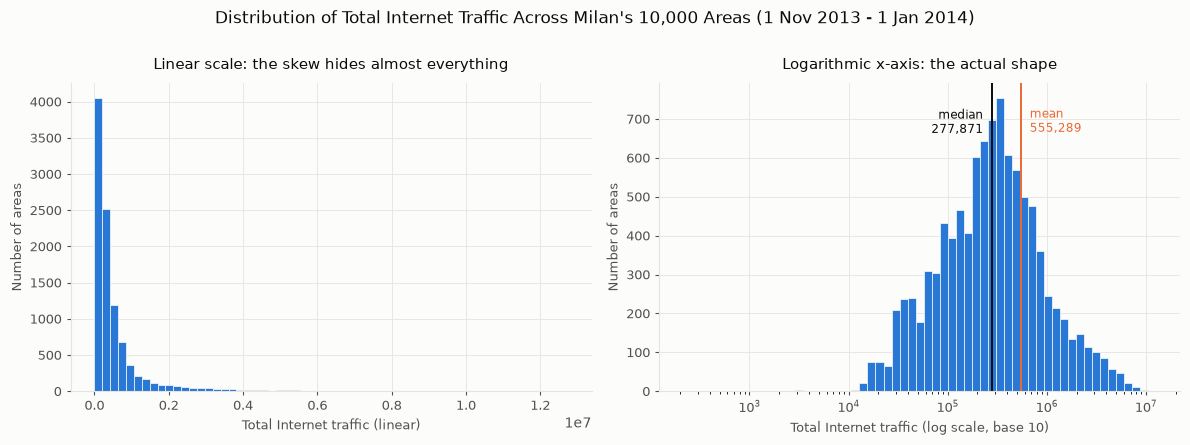

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), facecolor=SURFACE)

# The left panel uses linear bins to show why a linear axis fails here.
ax = axes[0]
style_axes(ax)
ax.hist(values, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.set_title("Linear scale: the skew hides almost everything",
             fontsize=11, color=INK, pad=10)
ax.set_xlabel("Total Internet traffic (linear)", fontsize=9.5, color=INK_2)
ax.set_ylabel("Number of areas", fontsize=9.5, color=INK_2)

# The right panel uses log-spaced bins on a log x-axis.
ax = axes[1]
style_axes(ax)
bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 60)
ax.hist(values, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.set_xscale("log")
ax.axvline(values.median(), color=INK, linewidth=1.4)
ax.axvline(values.mean(), color=ORANGE, linewidth=1.4)
ax.annotate("median\n%s" % format(values.median(), ",.0f"),
            xy=(values.median(), ax.get_ylim()[1] * 0.92),
            xytext=(-6, 0), textcoords="offset points",
            ha="right", va="top", fontsize=8.5, color=INK)
ax.annotate("mean\n%s" % format(values.mean(), ",.0f"),
            xy=(values.mean(), ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points",
            ha="left", va="top", fontsize=8.5, color=ORANGE)
ax.set_title("Logarithmic x-axis: the actual shape",
             fontsize=11, color=INK, pad=10)
ax.set_xlabel("Total Internet traffic (log scale, base 10)",
              fontsize=9.5, color=INK_2)
ax.set_ylabel("Number of areas", fontsize=9.5, color=INK_2)

fig.suptitle("Distribution of Total Internet Traffic Across Milan's "
             "10,000 Areas (1 Nov 2013 - 1 Jan 2014)",
             fontsize=12.5, color=INK, y=1.0)
fig.tight_layout()
plt.show()

### 4.2 The three busiest areas

The spread above is so uneven that the choice of forecasting areas really matters. I ranked all 10,000 squares by their total Internet traffic over the whole period and kept the top three. Working with busy areas also keeps the traffic values big enough for percentage errors to stay meaningful. That becomes important later on, when MAPE is reported.

There is one point I want to make here rather than bury it in the limitations. This ranking uses the totals over all 62 days, including the evaluation week. The choice of which areas to forecast was therefore not made blind to the test period.

In [7]:
top3 = totals.nlargest(3, "total_internet_traffic").reset_index(drop=True)
top3.index = ["Rank 1", "Rank 2", "Rank 3"]
display(top3.round(3))

lowest = totals.nsmallest(2, "total_internet_traffic")
print("For contrast, the two lowest areas:")
for _, row in lowest.iterrows():
    print("   square %d: %.2f" % (row.square_id, row.total_internet_traffic))

,square_id,total_internet_traffic
Rank 1,5161,1.274006e+07
Rank 2,5059,1.117085e+07
Rank 3,5259,1.048578e+07


For contrast, the two lowest areas:
   square 5239: 213.63
   square 5339: 691.21


Squares 5239 and 5339 were also absent from some daily files, and the reason for
that is not known so none is assumed here.

### 4.3 First two weeks for five areas

The assignment also asks for Squares 4159 and 4556 alongside the three busiest areas, so all five series are drawn together here. Two weeks is long enough for the daily rhythm to repeat and for weekdays and weekends to be compared. It is still short enough to read each day on its own.

What I am looking for here is whether these areas behave in the same way. If they all rise and fall together, one model tuned once would probably do for all of them. If their peaks arrive at different times of day, or the weekend affects them differently, then comparing models across areas becomes a real question rather than a formality. The plots cover 1 to 14 November in Milan local time, and the weekends are shaded.

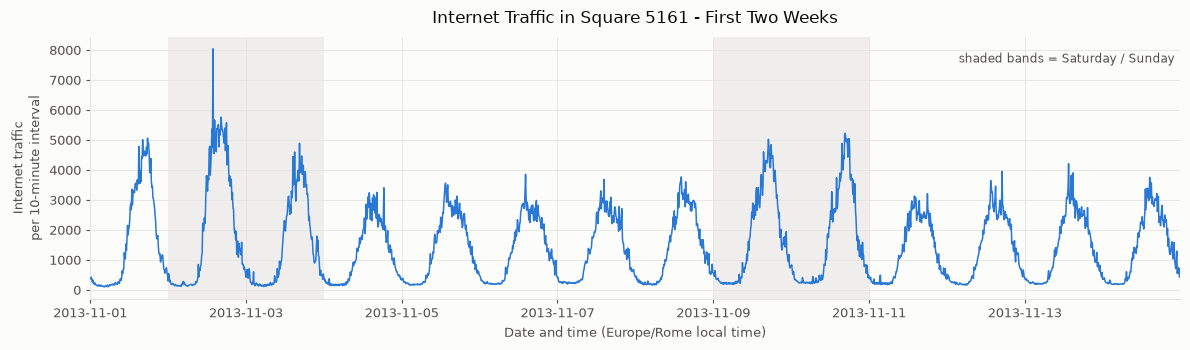

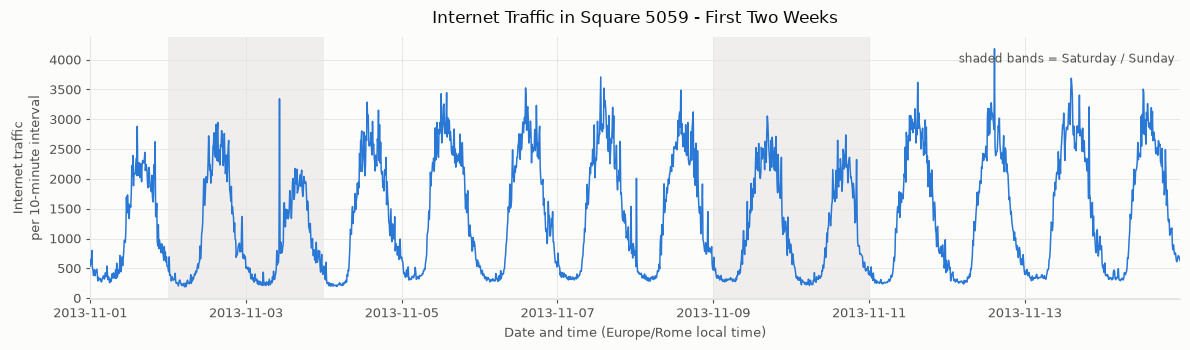

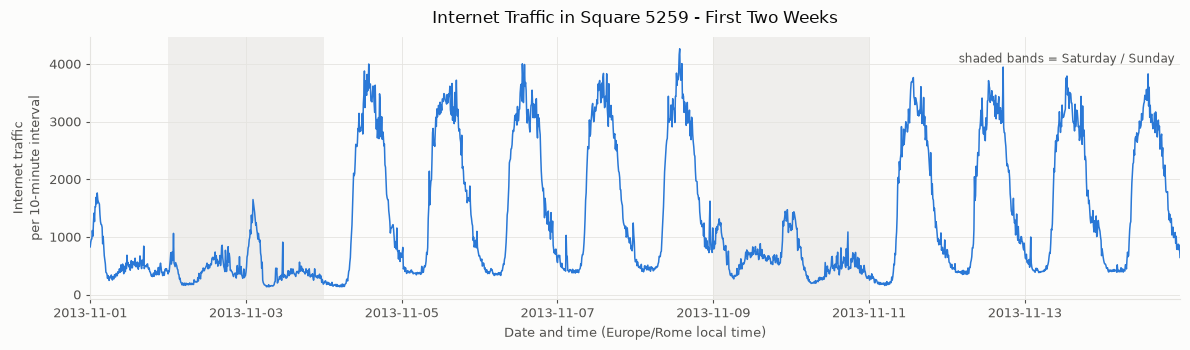

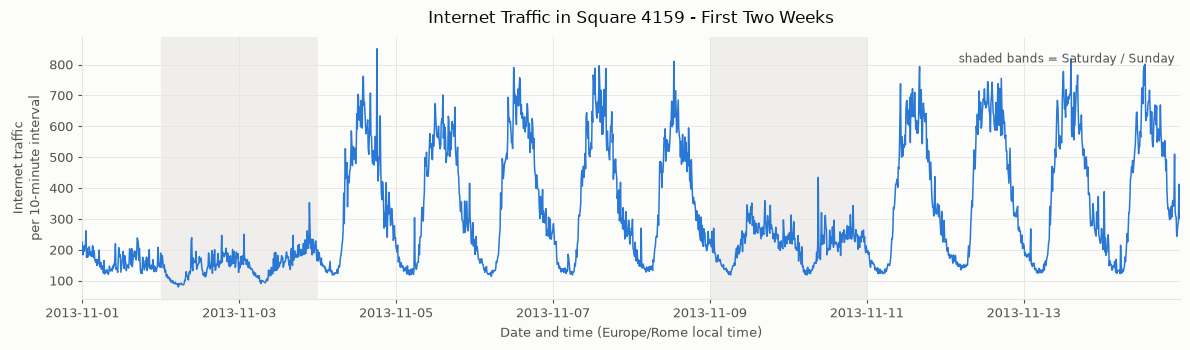

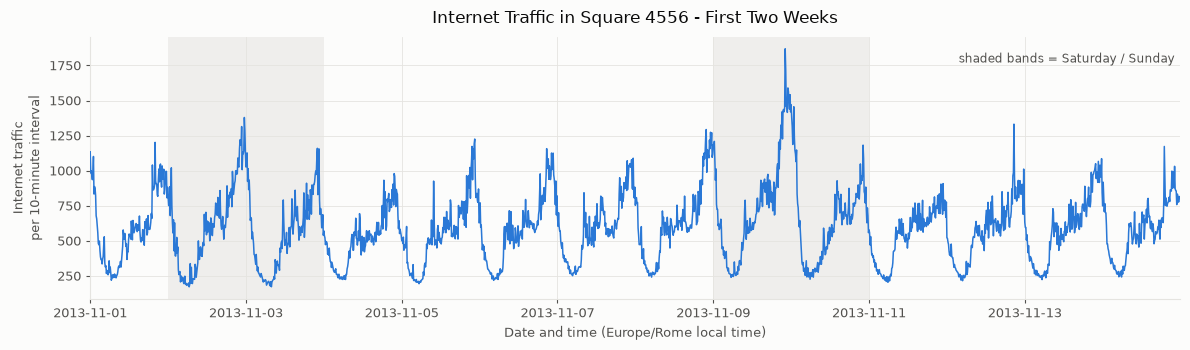

In [8]:
week_start = pd.Timestamp("2013-11-01 00:00", tz=TZ)
week_end = pd.Timestamp("2013-11-14 23:50", tz=TZ)

for square in [5161, 5059, 5259, 4159, 4556]:
    part = series[(series.square_id == square)
                  & (series.datetime >= week_start)
                  & (series.datetime <= week_end)].sort_values("datetime")

    fig, ax = plt.subplots(figsize=(12, 3.6), facecolor=SURFACE)
    style_axes(ax)

    # Saturdays and Sundays are shaded, which is only a calendar fact.
    for day in pd.date_range(week_start.normalize(), week_end.normalize(),
                             freq="D", tz=TZ):
        if day.dayofweek >= 5:
            ax.axvspan(day.tz_localize(None),
                       (day + pd.Timedelta(days=1)).tz_localize(None),
                       color=GRIDCOL, alpha=0.55, linewidth=0, zorder=0)

    ax.plot(part["datetime"].dt.tz_localize(None), part["internet_traffic"],
            color=BLUE, linewidth=1.1, zorder=3)
    ax.set_xlim(week_start.tz_localize(None), week_end.tz_localize(None))
    ax.set_title("Internet Traffic in Square %d - First Two Weeks" % square,
                 fontsize=12, color=INK, pad=10)
    ax.set_xlabel("Date and time (Europe/Rome local time)",
                  fontsize=9.5, color=INK_2)
    ax.set_ylabel("Internet traffic\nper 10-minute interval",
                  fontsize=9.5, color=INK_2)
    ax.annotate("shaded bands = Saturday / Sunday", xy=(0.995, 0.94),
                xycoords="axes fraction", ha="right", va="top",
                fontsize=8.5, color=INK_2)
    fig.tight_layout()
    plt.show()

In [9]:
# These are the five areas used in the exploratory analysis.
FIVE_AREAS = [5161, 5059, 5259, 4159, 4556]

# Every number here is computed from the processed series file.
def area_characteristics(area):
    block = series[series.square_id == area].sort_values("datetime")
    v = block["internet_traffic"].to_numpy(dtype=float)
    when = pd.to_datetime(block["datetime"], utc=True).dt.tz_convert(TZ)
    span = (when.max() - when.min())
    expected = int(span.total_seconds() // 600) + 1
    return {"square_id": area,
            "expected_intervals": expected,
            "observed_intervals": len(v),
            "mean": v.mean(),
            "median": float(np.median(v)),
            "std": v.std(ddof=1),
            "min": v.min(),
            "max": v.max(),
            "coef_variation": v.std(ddof=1) / v.mean(),
            "peak_to_mean": v.max() / v.mean(),
            "total": v.sum()}


characteristics = pd.DataFrame(
    [area_characteristics(a) for a in FIVE_AREAS])
display(characteristics.round(3))


def weekend_weekday_ratio(area):
    """Calculate the weekend to weekday ratio over the first two weeks."""
    block = series[series.square_id == area].copy()
    when = pd.to_datetime(block["datetime"], utc=True).dt.tz_convert(TZ)
    first = block[when < pd.Timestamp("2013-11-15", tz=TZ)]
    w = pd.to_datetime(first["datetime"], utc=True).dt.tz_convert(TZ)
    weekend = first[w.dt.dayofweek >= 5]["internet_traffic"]
    weekday = first[(w.dt.dayofweek < 5)
                    & (w.dt.normalize() != pd.Timestamp("2013-11-01", tz=TZ))]
    return weekend.mean() / weekday["internet_traffic"].mean()


ratios = pd.DataFrame({
    "square_id": FIVE_AREAS,
    "first-two-week weekend/weekday traffic ratio":
        [weekend_weekday_ratio(a) for a in FIVE_AREAS]})
print("Weekend/weekday mean-traffic ratio over the first two weeks")
print("(1 November excluded from the weekday side):")
display(ratios.round(3))


,square_id,expected_intervals,observed_intervals,mean,median,std,min,max,coef_variation,peak_to_mean,total
0,5161,8928,8928,1426.978,859.451,1381.649,55.795,8044.070,0.968,5.637,1.274006e+07
1,5059,8928,8928,1251.216,901.207,961.472,108.987,4666.121,0.768,3.729,1.117085e+07
2,5259,8928,8928,1174.482,653.837,1102.825,72.542,4442.096,0.939,3.782,1.048578e+07
3,4159,8928,8928,274.881,205.517,181.329,47.264,940.891,0.660,3.423,2.454134e+06
4,4556,8928,8928,512.396,501.322,248.267,80.247,1868.742,0.485,3.647,4.574671e+06


Weekend/weekday mean-traffic ratio over the first two weeks
(1 November excluded from the weekday side):


,square_id,first-two-week weekend/weekday traffic ratio
0,5161,1.290
1,5059,0.754
2,5259,0.314
3,4159,0.489
4,4556,1.111


What the five plots show:

- All five areas repeat a daily rhythm, but **the time of the daily peak is different**. Squares 5161, 5059, 5259 and 4159 peak between 12:00 and 16:00, while Square 4556 peaks around 22:00.
- The height of the daily peaks changes from one day to the next. Square 5161 reaches about 3,000 on some days and about 5,000 on others.
- Weekdays and weekends are treated very differently from one area to another. The first-two-week weekend to weekday mean traffic ratios computed above show two of the five areas busier at weekends and three of them quieter.
- Friday 1 November behaves like a weekend day in four of the five areas. This is simply what the data shows, and no cause is claimed here.

## 5. Additional analyses of Square 5161

Square 5161 has the highest total Internet traffic of all the areas so I used it for the deeper time series analysis.

### 5.1 Autocorrelation

One lag is 10 minutes long, which means that 6 lags make an hour, 144 lags make a day and 1,008 lags make a full week.

In [10]:
square_5161 = series[series.square_id == 5161].sort_values("timestamp")
traffic_5161 = square_5161["internet_traffic"].to_numpy(dtype=float)

PER_DAY, PER_WEEK, MAX_LAG = 144, 1008, 1440
acf_all = acf(traffic_5161, nlags=MAX_LAG, fft=True)

reported = pd.DataFrame([
    {"lag": 1, "equals": "10 minutes"},
    {"lag": 6, "equals": "1 hour"},
    {"lag": PER_DAY, "equals": "1 day"},
    {"lag": 288, "equals": "2 days"},
    {"lag": PER_WEEK, "equals": "7 days"},
])
reported["ACF"] = [round(acf_all[lag], 4) for lag in reported["lag"]]
display(reported)

print("observations used       : %d" % len(traffic_5161))
print("first lag with ACF < 0.50: %d (%.1f hours)"
      % (np.argmax(acf_all < 0.50), np.argmax(acf_all < 0.50) * 10 / 60))
print("first zero crossing      : %d (%.1f hours)"
      % (np.argmax(acf_all < 0), np.argmax(acf_all < 0) * 10 / 60))
print("daily multiples          : "
      + ", ".join("%dd=%.3f" % (k, acf_all[k * PER_DAY]) for k in range(1, 8)))

,lag,equals,ACF
0,1,10 minutes,0.9871
1,6,1 hour,0.9388
2,144,1 day,0.8783
3,288,2 days,0.7696
4,1008,7 days,0.8377


observations used       : 8928
first lag with ACF < 0.50: 23 (3.8 hours)
first zero crossing      : 37 (6.2 hours)
daily multiples          : 1d=0.878, 2d=0.770, 3d=0.741, 4d=0.730, 5d=0.733, 6d=0.798, 7d=0.838


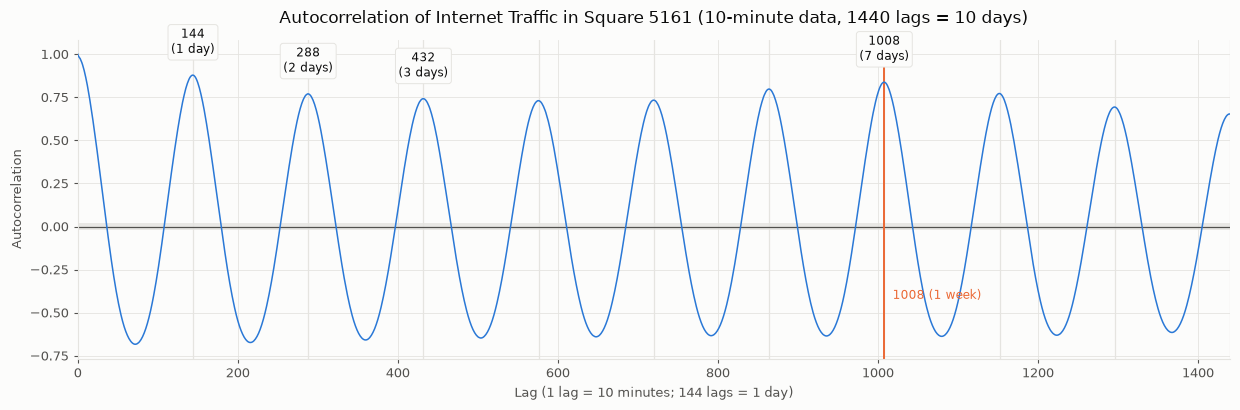

In [11]:
fig, ax = plt.subplots(figsize=(12.5, 4.2), facecolor=SURFACE)
style_axes(ax)
ax.axhline(0, color=INK_2, linewidth=0.9)

band = 1.96 / np.sqrt(len(traffic_5161))
ax.axhspan(-band, band, color=GRIDCOL, alpha=0.8, linewidth=0, zorder=0)
ax.plot(np.arange(len(acf_all)), acf_all, color=BLUE, linewidth=1.1, zorder=3)

for k in range(1, MAX_LAG // PER_DAY + 1):
    ax.axvline(k * PER_DAY, color=GRIDCOL, linewidth=0.9, zorder=1)
for k in (1, 2, 3, 7):
    lag = k * PER_DAY
    ax.annotate("%d\n(%d day%s)" % (lag, k, "" if k == 1 else "s"),
                xy=(lag, acf_all[lag]), xytext=(0, 16),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=INK, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", facecolor=SURFACE,
                          edgecolor=GRIDCOL, linewidth=0.7))
ax.axvline(PER_WEEK, color=ORANGE, linewidth=1.4, zorder=2)
ax.annotate("1008 (1 week)", xy=(PER_WEEK, -0.42), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=ORANGE)

ax.set_xlim(0, MAX_LAG)
ax.set_xlabel("Lag (1 lag = 10 minutes; 144 lags = 1 day)",
              fontsize=9.5, color=INK_2)
ax.set_ylabel("Autocorrelation", fontsize=9.5, color=INK_2)
ax.set_title("Autocorrelation of Internet Traffic in Square 5161 "
             "(10-minute data, %d lags = %d days)" % (MAX_LAG, MAX_LAG // PER_DAY),
             fontsize=12, color=INK, pad=12)
fig.tight_layout()
plt.show()

Three things are visible:

1. **Short term dependence is very strong but it fades within a few hours:** The correlation is 0.987 at 10 minutes and 0.939 at one hour. It then drops below 0.50 by lag 23, which works out at about 3.8 hours.
2. **The daily cycle is the strongest pattern of all:** Every clear peak sits exactly on a multiple of 144 lags.
3. **There is a weekly pattern as well:** The daily peaks fall from 0.878 at one day to about 0.730 at four and five days. They then climb back to 0.798 at six days and 0.838 at seven days, before dropping away. That small rise at exactly one week is the sign of a weekly structure.

There is one important limit to this evidence, because autocorrelation only measures how closely the series follows a shifted copy of itself in a straight line, and it does not prove that one lag will predict better than another. I used it to decide which lags were worth offering to a model, and the real usefulness of those lags still had to be confirmed by experiment later on.

### 5.2 Seasonal decomposition

I used STL with a daily period of 144 observations [12]. The seasonal strength below is worked out again here from the saved components. It uses the formula of Wang, Smith and Hyndman [13], as written in Hyndman and Athanasopoulos [14]:

F_S = max(0, 1 - Var(R) / Var(S + R))

In [12]:
stl_index = pd.DatetimeIndex(
    pd.to_datetime(square_5161["datetime"], utc=True).dt.tz_convert(TZ))
stl_result = STL(pd.Series(traffic_5161, index=stl_index),
                 period=PER_DAY, robust=True).fit()

observed = stl_result.observed
trend = stl_result.trend
seasonal = stl_result.seasonal
resid = stl_result.resid

var_resid = float(np.var(resid, ddof=1))
seasonal_strength = max(0.0, 1 - var_resid / float(np.var(seasonal + resid, ddof=1)))
trend_strength = max(0.0, 1 - var_resid / float(np.var(trend + resid, ddof=1)))

print("STL settings: period = %d observations (24 h), robust = True" % PER_DAY)
print("seasonal strength F_S : %.3f" % seasonal_strength)
print("trend strength    F_T : %.3f" % trend_strength)
print("components add back to the observed series, max error %.2e"
      % float(np.abs(trend + seasonal + resid - observed).max()))

daily = seasonal.to_numpy().reshape(-1, PER_DAY)
print("correlation of the mean daily shape, days 1-31 vs 32-62: %.4f"
      % np.corrcoef(daily[:31].mean(axis=0), daily[31:].mean(axis=0))[0, 1])


STL settings: period = 144 observations (24 h), robust = True
seasonal strength F_S : 0.858
trend strength    F_T : 0.236
components add back to the observed series, max error 9.09e-13
correlation of the mean daily shape, days 1-31 vs 32-62: 0.9929


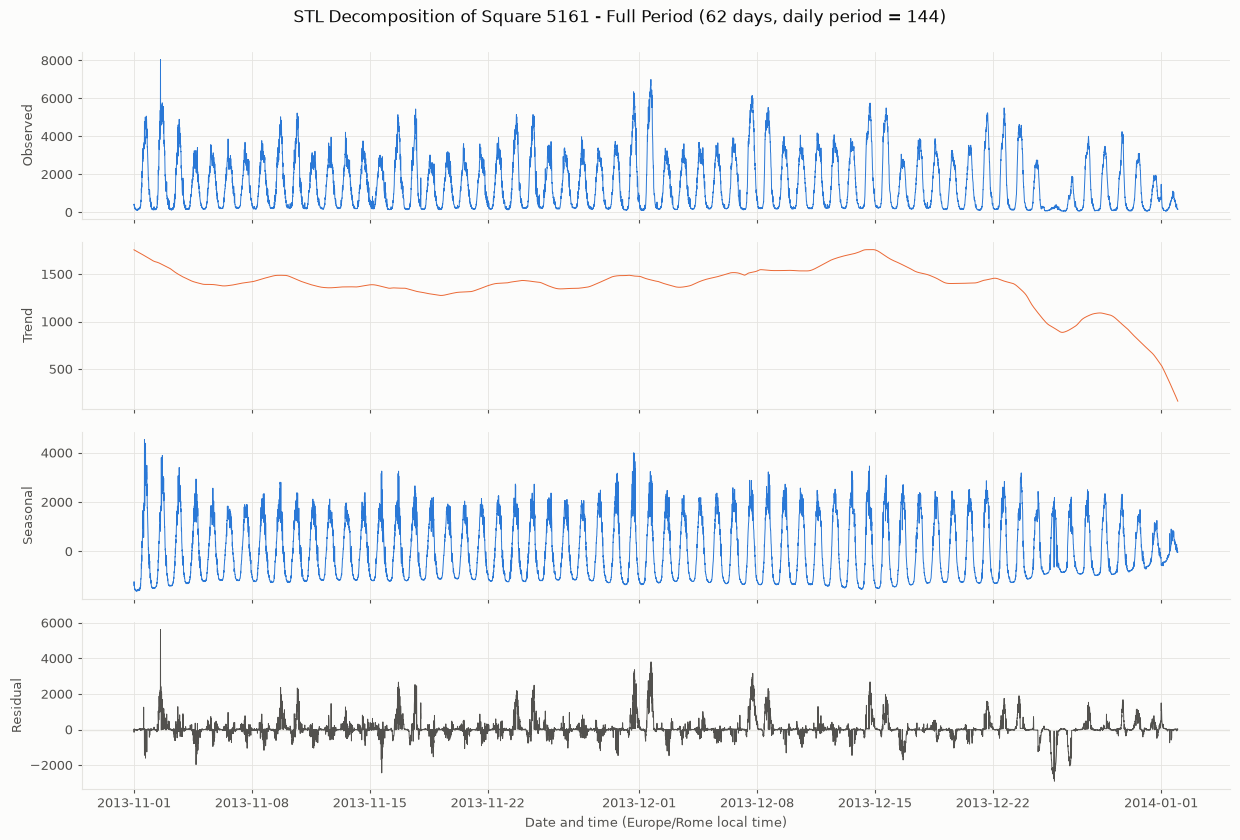

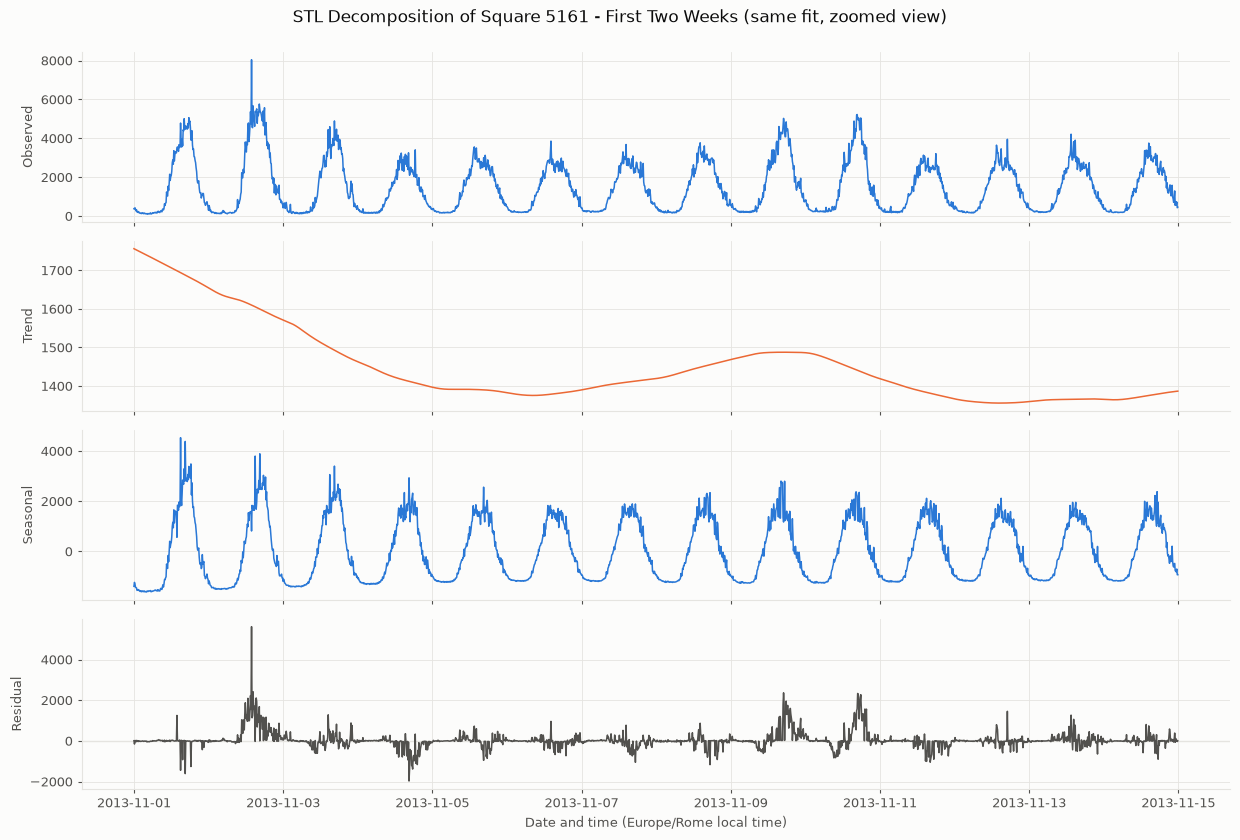

In [13]:
def draw_decomposition(mask, title, linewidth):
    fig, axes = plt.subplots(4, 1, figsize=(12.5, 8.4), sharex=True,
                             facecolor=SURFACE)
    panels = [("Observed", observed[mask], BLUE),
              ("Trend", trend[mask], ORANGE),
              ("Seasonal", seasonal[mask], BLUE),
              ("Residual", resid[mask], INK_2)]
    for ax, (label, data, colour) in zip(axes, panels):
        style_axes(ax)
        if label == "Residual":
            ax.axhline(0, color=GRIDCOL, linewidth=1.0)
        ax.plot(data.index.tz_localize(None), data.to_numpy(), color=colour,
                linewidth=linewidth)
        ax.set_ylabel(label, fontsize=9.5, color=INK_2)
    axes[-1].set_xlabel("Date and time (Europe/Rome local time)",
                        fontsize=9.5, color=INK_2)
    fig.suptitle(title, fontsize=12, color=INK, y=0.995)
    fig.tight_layout()
    plt.show()


draw_decomposition(np.ones(len(observed), dtype=bool),
                   "STL Decomposition of Square 5161 - Full Period "
                   "(62 days, daily period = 144)", 0.7)

two_weeks = ((observed.index >= pd.Timestamp("2013-11-01 00:00", tz=TZ))
             & (observed.index <= pd.Timestamp("2013-11-14 23:50", tz=TZ)))
draw_decomposition(two_weeks,
                   "STL Decomposition of Square 5161 - First Two Weeks "
                   "(same fit, zoomed view)", 1.1)

### 5.3 Stationarity check

An Augmented Dickey-Fuller test is run below on the same series. The null hypothesis it tests is that the series contains a unit root.

In [14]:
# result_object=False keeps the tuple return and silences a warning.
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(
    traffic_5161, autolag="AIC", result_object=False)

print("test statistic     : %.6f" % adf_stat)
print("p-value            : %.6g" % adf_p)
print("lags used          : %d" % adf_lags)
print("observations used  : %d" % adf_nobs)
print("critical values    :")
for level, value in adf_crit.items():
    print("    %-4s : %.6f" % (level, value))
print()
print("statistic below the 1% critical value:", adf_stat < adf_crit["1%"])

test statistic     : -19.031899
p-value            : 0
lags used          : 36
observations used  : 8891
critical values    :
    1%   : -3.431086
    5%   : -2.861865
    10%  : -2.566943

statistic below the 1% critical value: True


The test statistic comes out far below the 1 percent critical value so there is **no evidence of a standard unit root** in this series.

That does not mean the series is free of anything that could cause trouble. Strong seasonality is still there, with a seasonal strength of 0.858 and a daily swing several times bigger than the mean level. The traffic level itself also shifts over the last two weeks, and a unit root test says nothing about either of those things.

## 6. Related work and model selection

### 6.1 Why these three models

I picked these three models so that the comparison would mean something, rather than being three versions of the same idea. Each of them looks at patterns over time in its own way.

**Selected-Lag Autoregressive model:** This is a linear model that predicts the next value from a set of earlier values that I choose myself. It acts as the clear reference point of the comparison, because the weights it learns can be read and checked one by one. The theory behind it has been standard for a long time [15], and it is not a token baseline either. Azari and colleagues found that ARIMA came close to optimal at much lower complexity in some cellular traffic settings [3]. Zeng and colleagues showed simple linear models beating far more complex architectures on several forecasting benchmarks [10].

There is also a practical reason why I did not use plain SARIMA. The daily season here is 144 steps long, which makes a seasonal ARIMA model heavy to set up and fit for a controlled comparison that has to run on a CPU. Picking the lags straight from the autocorrelation evidence gives me a model I can read, for far less work.

**LSTM:** This is a neural network that keeps its own memory of the sequence and updates it one step at a time. Its gates let the learning signal survive across long input windows [6], which matters because plain recurrent networks struggle once the dependencies get long [7]. It is a natural choice for this particular problem. Santos and colleagues used LSTM and GRU on this same Telecom Italia Milan dataset, and found that both picked up the daily and monthly seasonality [2]. Azari and colleagues found that LSTM beat ARIMA once there was enough training data [3]. A GRU would have been a reasonable cheaper swap, since Chung and colleagues could not separate the two [8], but the LSTM has the stronger track record on this dataset.

**Temporal Convolutional Network:** This is a network that slides filters over the past values, and reaches a long way back by spacing those filters out. Bai, Kolter and Koltun found that TCNs matched or beat recurrent networks while holding on to a longer memory [9]. It brings a genuinely different way of learning into the comparison, because it works through filters that run in parallel instead of stepping through the sequence one value at a time.

### 6.2 What our own evidence contributed

| Finding from our analysis | Model it supports |
|---|---|
| Lag 1 autocorrelation 0.987 | AR, and the persistence baseline |
| Lag 144 autocorrelation 0.878, seasonal strength 0.858 | AR daily lags, TCN long context |
| Local rise at lag 1008 | AR weekly lags, TCN long context |
| 3.23 percent of intervals beyond 3 residual standard deviations | Heavy-tailed residuals; recorded as a property of the series |
| Traffic level changes late in the period | Argues for evaluating on a fixed later window rather than a random split |
| Only 8,928 observations per area, CPU only, no CUDA GPU | Argues against very large models |

### 6.3 What was considered and left out

I did look at Transformer based forecasting and decided against it, because this project compares three smaller models on a CPU only budget, and attention grows with the square of the sequence length. The literature also shows that simple linear baselines can stay competitive, and Zeng and colleagues found linear models beating several Transformer variants across nine benchmarks [10]. I am not claiming anything here about the amount of data at which a Transformer would start to pay off.

The studies I lean on differ from mine in ways that matter, so I do not read their conclusions as directly transferable. Santos and colleagues used the same Milan dataset, which makes their result the closest to mine, but they report on a different selection of cells and their own split, so the numbers are not comparable to mine side by side [2]. Azari and colleagues worked on a different operator's cellular data, and their LSTM advantage appeared once enough training history was available, which is a condition my 8,928 observations per area may not meet [3]. Bai, Kolter and Koltun evaluated TCNs on generic sequence benchmarks rather than on network traffic, so their conclusion is about architecture families and not about this signal [9]. Zeng and colleagues compared against Transformers on long-horizon forecasting tasks, while my task is a single step ahead, and a linear model has a much easier job at one step than at ninety-six [10]. The M4 competition covers 100,000 series of many kinds at yearly to hourly frequency, none of them mobile traffic at ten-minute resolution [11].

Zhang and Patras used spatial neural networks on this same dataset and got strong results [4]. Their approach needs many cells at once, which means their models see information mine never receive. Their stronger numbers therefore cannot be attributed to the architecture alone, because the inputs differ as well. This investigation looks at one area at a time on purpose, and that is a limit I record in Section 17.

Makridakis and colleagues found that simple benchmarks were hard to beat across 100,000 series [11]. That is exactly why persistence and the seasonal naive forecasts are measured here, instead of being assumed to be weak.

All the DOIs cited here were checked against Crossref, arXiv or DataCite instead of being written from memory.

## 7. Experimental setup

### 7.1 Chronological split

The data was split by time and never at random, because a random split would let a model learn from the future in order to predict the past, which would make the whole result meaningless for forecasting.

In [15]:
TZ = "Europe/Rome"
periods = [
    ("Training", "2013-11-01 00:00", "2013-12-08 23:50"),
    ("Validation", "2013-12-09 00:00", "2013-12-15 23:50"),
    ("Final test", "2013-12-16 00:00", "2013-12-22 23:50"),
    ("Unused after test", "2013-12-23 00:00", "2014-01-01 23:50"),
]

one_area = series[series.square_id == 5161].sort_values("timestamp")
rows = []
for name, start, end in periods:
    lo = pd.Timestamp(start, tz=TZ)
    hi = pd.Timestamp(end, tz=TZ)
    count = ((one_area["datetime"] >= lo) & (one_area["datetime"] <= hi)).sum()
    rows.append({"period": name, "from": start, "to": end,
                 "observations per area": int(count),
                 "days": int(count / 144)})
split_table = pd.DataFrame(rows)
display(split_table)

print("total accounted for: %d of %d observations"
      % (split_table["observations per area"].sum(), len(one_area)))

,period,from,to,observations per area,days
0,Training,2013-11-01 00:00,2013-12-08 23:50,5472,38
1,Validation,2013-12-09 00:00,2013-12-15 23:50,1008,7
2,Final test,2013-12-16 00:00,2013-12-22 23:50,1008,7
3,Unused after test,2013-12-23 00:00,2014-01-01 23:50,1440,10


total accounted for: 8928 of 8928 observations


The final test week holds exactly 1,008 targets for each area, because 7 days multiplied by 144 ten minute intervals gives 1,008. The data after 22 December was never used to fit a forecasting model. It was never used to pick a configuration on validation, nor for the official test evaluation. The exploratory analysis in sections 4 and 5 did use the complete 62-day series, so it included that later stretch. No model was ever trained on it.

### 7.2 Rolling one-step-ahead prediction

The task is one-step-ahead forecasting. A model is allowed to use the actual observations up to and including time t when it predicts the value at time t+1.

Predictions are never fed back in as inputs and that matters in two ways:

- It is not recursive multi-step forecasting.
- Because the inputs are always real observations, **all 1,008 test targets are predicted**. None of them are lost to a warm-up window at the start of the test week. The first prediction uses history from before 16 December. The later ones use earlier actual values from inside the test week, which would genuinely have been known by then.

### 7.3 What the exploratory analysis saw

There is one thing I need to say clearly before the leakage checks. It changes how the final numbers should be read.

The exploratory analysis in sections 4 and 5 covers the autocorrelation, the STL decomposition and the stationarity test. All of it was done on the **full 62-day Square 5161 series**, which contains the validation week, the official 16 to 22 December evaluation week and the later stretch from 23 December to 1 January. Section 5.1 says openly that this evidence helped me decide which lags and history lengths were worth offering to the models.

This means the design of the candidates was shaped by statistics computed over a period that includes the evaluation week. Here is what that does and does not mean:

- No model was ever **fitted** on test data. Training used only 1 November to 8 December, and the scaler parameters were fitted on training values alone.
- The final choice among the tested configurations was made on **validation metrics**. The final test metrics were never used to choose or change any configuration.
- The 16 to 22 December week still has to be read as **the assignment's official evaluation window and not as a completely untouched holdout**. Statistics from the full period helped shape the lag and context length candidates.

I am writing this down openly instead of quietly fixing it afterwards. Redoing the exploratory analysis on training data alone now, and then presenting that as the original process, would misrepresent how the work actually happened.

### 7.4 Leakage prevention

These are the checks that were run and passed:

- The training targets end strictly before validation begins.
- The validation targets end strictly before test begins.
- No test index shows up in any set of training targets.
- Every input lag is at least 1 so a target can never appear inside its own input row.
- The training, validation, and test periods stay in time order. During neural network training, the input windows are shuffled between batches, but the observations inside each window remain in their original order.

For the LSTM and the TCN a `StandardScaler` was fitted **on training values only** for each area. It was then applied unchanged to the validation and test values. Every model output was turned back into the original traffic scale before any metric was worked out.

### 7.5 Error measures

For actual values y and predictions y-hat over n points:

- **MAE**(mean absolute error) - `mean(|y_hat - y|)`: This is the average size of the mistake in traffic units and it is the easiest one to read because every error counts the same.
- **RMSE**(root mean squared error) - `sqrt(mean((y_hat - y)^2))`: This is also in traffic units but it squares the errors first so a few big mistakes weigh far more than many small ones.
- **MAPE**(mean absolute percentage error) - `mean(|y_hat - y| / |y|) * 100`: This gives the size of the mistake compared with the actual value.

MAPE has a known weakness that matters later on, because the actual value sits on the bottom of the fraction. The same mistake in traffic units therefore looks far bigger in percentage terms whenever traffic is low.

Every actual value in the test week was checked and found to be above zero. Ordinary MAPE was therefore safe to use, and there was no need to add a small number to the denominator.

In [16]:
predictions = pd.read_csv(RESULTS / "final_predictions.csv")
predictions["timestamp"] = pd.to_datetime(predictions["timestamp"], utc=True).dt.tz_convert(TZ)

check = predictions.groupby("square_id")["actual"].agg(["count", "min"])
check.columns = ["test targets", "minimum actual value"]
display(check.round(3))
print("any actual value equal to zero:", bool((predictions["actual"] == 0).any()))

,test targets,minimum actual value
square_id,,
5059,1008,182.261
5161,1008,108.154
5259,1008,161.446


any actual value equal to zero: False


### 7.6 Training settings for the neural models

I used the same optimiser and the same stopping rule for both neural models, so those
factors are controlled. The comparison is still not a clean architecture test, because the
input window, the width and the parameter count all differ as well. These are the frozen settings:

| Setting | LSTM | TCN |
|---|---|---|
| Optimiser | Adam | Adam |
| Learning rate | 0.001 | 0.001 |
| Batch size | 64 | 64 |
| Loss | mean squared error | mean squared error |
| Maximum epochs | 100 | 100 |
| Early stopping patience | 10 | 10 |
| Random seed | 42 | 42 |
| Input window | 36 steps, which is 6 hours | 288 steps, which is 48 hours |
| Width | 64 hidden units | 32 channels |
| Parameters | 17,217 | 40,577 |

The two models do not receive the same amount of history, and that is deliberate. Each one
was given the window that performed best for it on validation. I return to what that means
for the comparison in Section 17.

## 8. Baselines

I measured three baselines. They are there as benchmarks only, and are never treated as selected models.

- **Persistence** predicts the next value by simply repeating the current one.
- **Daily seasonal naive** predicts by repeating the value from 144 steps back which is the same time yesterday.
- **Weekly seasonal naive** predicts by repeating the value from 1,008 steps back which is the same time last week.

Persistence matters most of the three, because the lag 1 autocorrelation is 0.987. Any model that cannot beat it has not shown that it brings anything useful.

In [17]:
log = pd.read_csv(RESULTS / "experiment_log.csv")
baseline_ids = {"BASE-PERS-TES": "Persistence",
                "BASE-DAIL-TES": "Daily seasonal naive",
                "BASE-WEEK-TES": "Weekly seasonal naive"}
baselines = log[log.experiment_id.isin(baseline_ids)].copy()
baselines["Baseline"] = baselines.experiment_id.map(baseline_ids)

table = (baselines.pivot_table(index="Baseline", columns="area",
                               values=["MAE", "RMSE", "MAPE"])
         .round(3))
display(table)

print("Mean across the three areas:")
display(baselines.groupby("Baseline")[["MAE", "RMSE", "MAPE"]].mean().round(3))

MAE                      MAPE                     RMSE                  
area                      5059     5161     5259    5059    5161    5259     5059     5161     5259
Baseline                                                                                           
Daily seasonal naive   171.736  338.594  470.321  18.019  25.940  71.621  245.870  619.040  861.621
Persistence             81.517   92.802   75.968   7.959   9.194   8.115  114.375  134.878  109.578
Weekly seasonal naive  259.950  300.750  210.241  25.731  28.969  28.563  361.120  432.955  289.495

Mean across the three areas:


,MAE,RMSE,MAPE
Baseline,,,
Daily seasonal naive,326.883,575.51,38.526
Persistence,83.429,119.61,8.423
Weekly seasonal naive,256.980,361.19,27.755


The result is not what the autocorrelation on its own would lead you to expect. Persistence is by far the best of the three baselines. The daily and weekly seasonal naive forecasts come out several times worse, even though the autocorrelation at lag 144 and lag 1008 is high.

Two things I can see in my own data fit with that result although neither of them was shown to be the cause:

- Both evaluation weeks contain a weekend, so repeating the value from exactly 24 hours earlier has to cross the line between a weekday and a weekend twice in every week.
- Square 5259 had by far the biggest gap between weekdays and weekends in the first two weeks. It is also the area where the daily seasonal naive does worst, with a MAPE above 70 percent.

The safe conclusion is a narrower one. A high autocorrelation at some lag does not on its own make a forecast built on that lag accurate.

## 9. Autoregressive model experiments

### 9.1 Four controlled lag structures

I compared four lag structures as four controlled experiments rather than as a chain where each one changes a single thing from the experiment right before it.

| ID | Idea being tested | Lags | Parameters |
|---|---|---|---|
| AR-1 | Short term memory only, one hour | 1 to 6 | 7 |
| AR-2 | One complete daily window | 1 to 144 | 145 |
| AR-3 | Short term plus selected daily lags | 1-6, 143-145, 287-289 | 13 |
| AR-4 | AR-3 plus weekly lags | AR-3 plus 1007-1009 | 16 |

AR-1 and AR-2 include every single lag from 1 up to p, so they are true AR(6) and AR(144) models. AR-3 and AR-4 leave gaps in their lag sets, which is why I describe them as Selected-Lag models rather than AR(p).

All four models were trained on exactly the same set of target rows. The only thing that differs between them is the lag set, not the amount of training data.

In [18]:
ar_runs = log[log.experiment_id.isin(["AR-1", "AR-2", "AR-3", "AR-4"])]
per_area = (ar_runs.pivot_table(index="experiment_id", columns="area",
                                values="MAE").round(3))
per_area.columns = ["MAE %d" % c for c in per_area.columns]

summary = ar_runs.groupby("experiment_id").agg(
    mean_MAE=("MAE", "mean"), mean_RMSE=("RMSE", "mean"),
    mean_MAPE=("MAPE", "mean"), parameters=("parameters", "first")).round(3)
display(per_area.join(summary))

best = summary["mean_MAE"].idxmin()
print("lowest mean validation MAE: %s" % best)
print("lowest mean validation RMSE: %s" % summary["mean_RMSE"].idxmin())

,MAE 5059,MAE 5161,MAE 5259,mean_MAE,mean_RMSE,mean_MAPE,parameters
experiment_id,,,,,,,
AR-1,101.760,112.037,82.862,98.886,143.345,8.634,7
AR-2,87.627,107.054,79.929,91.536,131.122,8.587,145
AR-3,93.872,106.064,81.506,93.814,137.300,8.003,13
AR-4,90.630,97.544,78.826,89.000,132.485,7.428,16


lowest mean validation MAE: AR-4
lowest mean validation RMSE: AR-2


### 9.2 Why AR-4 was selected

AR-4 was selected on mean validation MAE which was the rule I wrote down before running the experiments and the only rule I applied afterwards.

Two more things are worth writing down separately, because neither of them played any part in the decision. The first is that AR-2 had a slightly lower mean validation RMSE, 131.12 against 132.49, so AR-4 did **not** win every validation metric. The second is that AR-4 gets there with only 16 parameters, against 145 for AR-2.

The conditioning of the problem also favoured AR-4. The condition number of the design matrix sat around 1.1e4 to 1.2e4 for AR-4, but between 5.4e4 and 1.5e5 for AR-2. That is because 144 lags in a row taken from a smooth series are very close to one another, which makes AR-2 much harder to solve accurately. The independent numerical checks described next stayed stable in both cases, and nothing in the evidence showed that regularisation was needed, so I did not add any.

### 9.3 Independent verification

The model was fitted with `numpy.linalg.lstsq` which solves the least squares problem through an SVD and `inv(X.T @ X)` was never formed at any point.

I checked the result against two independent references on the same design matrices. The first was statsmodels OLS. The second was the normal equations solved with a Cholesky factorisation, which is a completely different algorithm from SVD. Both confirm the least squares solution and the predictions that come out of it.

| Comparison | Largest difference observed |
|---|---|
| Coefficients against statsmodels OLS | 4.75e-14 to 3.20e-12 |
| Coefficients against Cholesky | 1.78e-12 to 2.81e-10 |
| Predictions | 2.27e-12 to 1.73e-11 |

A separate lag index check confirmed that the design matrix really holds what it claims to hold. For hand picked target rows, every column was compared against `series[target - lag]`. All 15 lag columns matched exactly, and the intercept column was all ones.

One thing is worth making clear here, because it is easy to mix up: the fitted AR coefficients are **not** the ACF values. The autocorrelation only told me which lags were worth offering to the model. The weights themselves come out of a separate estimation problem.

## 10. LSTM experiments

I kept the architecture small on purpose because there are only 8,928 observations for each area and no GPU to train on.

### 10.1 Sequence length

Everything else was kept fixed and only the input sequence length was changed.

One limit applies to this comparison, and to the TCN version of it in section 11.4. Changing the sequence length also changes how many training sequences the fixed training window can produce. Every sequence needs that many earlier observations behind it. A longer window therefore trains on slightly fewer examples, which means the sequence length is not varied completely on its own.

In [19]:
lstm_a = log[log.experiment_id.isin(["LSTM-A1", "LSTM-A2", "LSTM-A3"])]
lengths = {"LSTM-A1": "36 steps (6 h)", "LSTM-A2": "72 steps (12 h)",
           "LSTM-A3": "144 steps (24 h)"}
view = lstm_a.pivot_table(index="experiment_id", columns="area",
                          values="MAE").round(3)
view.columns = ["MAE %d" % c for c in view.columns]
view["mean validation MAE"] = lstm_a.groupby("experiment_id")["MAE"].mean().round(3)
view["sequence length"] = [lengths[i] for i in view.index]
display(view)

print("lowest mean validation MAE: %s" % view["mean validation MAE"].idxmin())
print("spread between best and worst: %.3f MAE (%.1f%%)"
      % (view["mean validation MAE"].max() - view["mean validation MAE"].min(),
         100 * (view["mean validation MAE"].max() / view["mean validation MAE"].min() - 1)))

,MAE 5059,MAE 5161,MAE 5259,mean validation MAE,sequence length
experiment_id,,,,,
LSTM-A1,93.126,104.634,76.219,91.326,36 steps (6 h)
LSTM-A2,93.068,107.357,76.388,92.271,72 steps (12 h)
LSTM-A3,95.091,104.637,75.796,91.841,144 steps (24 h)


lowest mean validation MAE: LSTM-A1
spread between best and worst: 0.945 MAE (1.0%)


The 36-step window gave the lowest mean validation MAE, so I selected it. The difference between the best and worst settings was only about 1 percent. This means six hours of history worked best in these experiments, but it does not show that six hours is always enough.

This is interesting because the daily autocorrelation is strong and yet stretching the window out to a full day did not help the LSTM at all.

### 10.2 Hidden units

The sequence length was then fixed at 36 and only the number of hidden units was changed.

In [20]:
lstm_b = log[log.experiment_id.isin(["LSTM-B1", "LSTM-B2"])]
widths = {"LSTM-B1": 32, "LSTM-B2": 64}
view = lstm_b.pivot_table(index="experiment_id", columns="area",
                          values="MAE").round(3)
view.columns = ["MAE %d" % c for c in view.columns]
view["mean validation MAE"] = lstm_b.groupby("experiment_id")["MAE"].mean().round(3)
view["hidden units"] = [widths[i] for i in view.index]
view["parameters"] = lstm_b.groupby("experiment_id")["parameters"].first()
display(view)

gap = (view.loc["LSTM-B1", "mean validation MAE"]
       - view.loc["LSTM-B2", "mean validation MAE"])
print("64 units better by %.3f MAE, which is %.2f%%"
      % (gap, 100 * gap / view.loc["LSTM-B1", "mean validation MAE"]))

,MAE 5059,MAE 5161,MAE 5259,mean validation MAE,hidden units,parameters
experiment_id,,,,,,
LSTM-B1,93.126,104.634,76.219,91.326,32,4513
LSTM-B2,89.527,108.880,74.699,91.036,64,17217


64 units better by 0.290 MAE, which is 0.32%


64 hidden units was selected by the validation rule I had declared, but the evidence behind it is weak. The improvement is only about 0.3 percent, and it is not consistent across areas, because 64 units actually does worse on Square 5161. It also costs 3.8 times as many parameters. I stuck to the rule I had written down, rather than replacing it with my own judgement after seeing the numbers. The choice between 32 and 64 is still not well supported by this evidence.

It is also worth noting that LSTM-B1 is the same configuration as the selected LSTM-A1 setting. It appears in the experiment log for completeness, not as a separate modelling idea.

### 10.3 Learning curves and overfitting

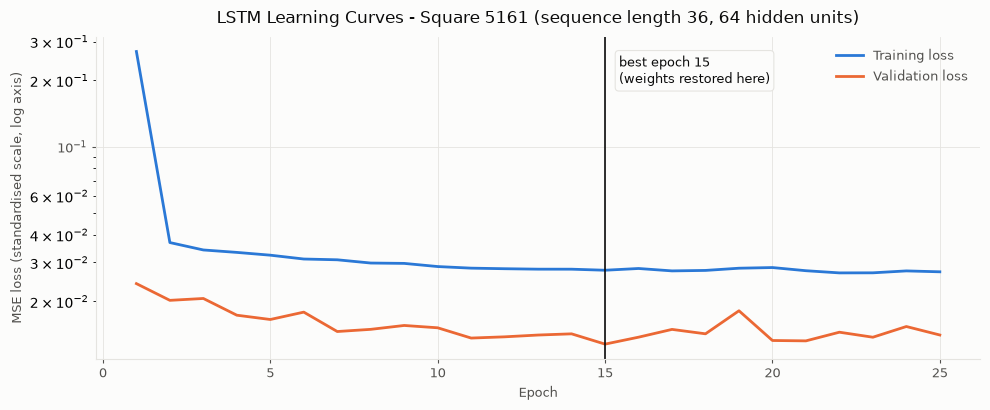

epochs run 25 | best epoch 15
train loss  first 0.27030  at best 0.02766  final 0.02721
valid loss  first 0.02406  at best 0.01280  final 0.01408
validation loss at the end is +10.0% versus its best


In [21]:
import json


def plot_learning_curves(path, title, subtitle):
    """Draw the saved training history without retraining anything."""
    with open(path, encoding="utf-8") as handle:
        history = json.load(handle)["5161"]
    train, valid = history["train"], history["valid"]
    best = history["best_epoch"]
    epochs = range(1, len(train) + 1)

    fig, ax = plt.subplots(figsize=(10, 4.2), facecolor=SURFACE)
    style_axes(ax)
    ax.plot(epochs, train, color=BLUE, linewidth=2, label="Training loss")
    ax.plot(epochs, valid, color=ORANGE, linewidth=2, label="Validation loss")
    ax.axvline(best, color=INK, linewidth=1.2)
    label = "best epoch %d" % best + chr(10) + "(weights restored here)"
    ax.annotate(label, xy=(best, max(train) * 0.72), xytext=(10, 0),
                textcoords="offset points", fontsize=9, color=INK,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=SURFACE,
                          edgecolor=GRIDCOL, linewidth=0.8))
    ax.set_yscale("log")
    ax.set_xlabel("Epoch", fontsize=9.5, color=INK_2)
    ax.set_ylabel("MSE loss (standardised scale, log axis)",
                  fontsize=9.5, color=INK_2)
    ax.set_title("%s - Square 5161 (%s)" % (title, subtitle),
                 fontsize=12, color=INK, pad=10)
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2)
    fig.tight_layout()
    plt.show()

    print("epochs run %d | best epoch %d" % (len(train), best))
    print("train loss  first %.5f  at best %.5f  final %.5f"
          % (train[0], train[best - 1], train[-1]))
    print("valid loss  first %.5f  at best %.5f  final %.5f"
          % (valid[0], valid[best - 1], valid[-1]))
    print("validation loss at the end is %+.1f%% versus its best"
          % (100 * (valid[-1] - valid[best - 1]) / valid[best - 1]))


plot_learning_curves(RESULTS / "lstm_learning_curves.json",
                     "LSTM Learning Curves",
                     "sequence length 36, 64 hidden units")

The validation loss falls until it reaches its lowest point at epoch 15. After that it moves sideways with some noise, rather than climbing steadily. Training stopped at epoch 25, and the weights from epoch 15 were put back.

There was no lasting rise in the validation loss strong enough to justify an extra regularisation experiment, and early stopping had already restored the best validation weights, so no dropout and no weight decay were added.

One detail is worth reporting, because it looked strange at first: the training loss sits **above** the validation loss the whole way through. A descriptive check showed that the validation week is not a calmer stretch of data. Its mean is 1.10 to 1.12 times the training mean, and its standard deviation is 1.05 to 1.13 times the training standard deviation, with a similar coefficient of variation. The easy explanation that validation was simply easier does not hold up. Two things fit with what I observed, although neither of them was shown to be the cause. The training loss is averaged across a whole epoch while the weights are still changing. The training period also holds the largest extreme values in the series, which a squared error loss punishes heavily.

## 11. TCN experiments

### 11.1 Architecture

The TCN is a causal residual network rather than a generic convolutional network.

```
input (1 channel) -> 7 residual blocks -> linear head on the last time position

each residual block:
    Conv1d(kernel 3, dilation d) -> trim right padding -> ReLU
    Conv1d(kernel 3, dilation d) -> trim right padding -> ReLU
    plus a residual connection
    -> ReLU

dilations: 1, 2, 4, 8, 16, 32, 64
```

Padding is added on the left, and the extra padding on the right is cut off again. The representation at time t can therefore never reach values that come after it. Nothing in the network reads the sequence in both directions.

### 11.2 Receptive field

The structural receptive field follows directly from the architecture:

`1 + 2 * (kernel_size - 1) * sum(dilations) = 1 + 2 * 2 * 127 = 509`

This is checked in practice by `scripts/tcn_model.py --stage verify`, rather than taken on trust. A randomly initialised network is not a reliable way to test it, because ReLU can shut a connected path down to zero, which would make a correct architecture look smaller than it really is. The check therefore sets every weight to a small positive constant and every bias to zero. With a non-negative input, every pre-activation is then non-negative, and ReLU passes it through untouched. Any position that is wired to the output must therefore change it. The probe is deterministic and depends only on the architecture, and it returns 509 for both channel widths on every run.

Two things follow from that and they should not be mixed up:

- **509 is the maximum structural receptive field** of this architecture. It describes how far back the output is wired to reach.
- **The frozen model's actual available history is 288 observations**, because the input window is 288 steps long. The limit here comes from the input window, not from the dilation stack.

### 11.3 Causality verification

I built two sequences that are identical up to position 150 and different after it. I then compared what happens to them inside the network. The model used for this check is seeded, so `--stage verify` reports the same numbers on every run.

For the frozen 32-channel configuration the deterministic causality check gave:

| Check | Result |
|---|---|
| Largest difference at position 150 | 0.000e+00 |
| Largest difference at positions up to 150 | 0.000e+00 |
| Largest difference at positions after 150 | 2.690e+02 |
| Input length equals output temporal length | True (300) |

The representation before and at the split point is identical, which is exactly what causal padding has to guarantee. Some difference has to show up after the split, and it does, but the size of that difference is not a measure of performance. It only has to be something other than zero, and its value depends on the seeded random weights. The temporal length is also kept the same, which shows that the head really is reading the last position.

### 11.4 Sequence length

In [22]:
tcn_a = log[log.experiment_id.isin(["TCN-A1", "TCN-A2", "TCN-A3"])]
lengths = {"TCN-A1": "36 steps (6 h)", "TCN-A2": "144 steps (1 day)",
           "TCN-A3": "288 steps (2 days)"}
view = tcn_a.pivot_table(index="experiment_id", columns="area",
                         values="MAE").round(3)
view.columns = ["MAE %d" % c for c in view.columns]
view["mean validation MAE"] = tcn_a.groupby("experiment_id")["MAE"].mean().round(3)
view["sequence length"] = [lengths[i] for i in view.index]
display(view)

a2 = view.loc["TCN-A2", "mean validation MAE"]
a3 = view.loc["TCN-A3", "mean validation MAE"]
a1 = view.loc["TCN-A1", "mean validation MAE"]
print("36 to 144 improved mean validation MAE by %.3f (%.1f%%)"
      % (a1 - a2, 100 * (a1 - a2) / a1))
print("144 to 288 changed it by %.3f (%.2f%%)" % (a2 - a3, 100 * (a2 - a3) / a2))

,MAE 5059,MAE 5161,MAE 5259,mean validation MAE,sequence length
experiment_id,,,,,
TCN-A1,88.553,108.757,75.714,91.008,36 steps (6 h)
TCN-A2,88.381,100.961,73.139,87.494,144 steps (1 day)
TCN-A3,87.476,101.514,73.236,87.409,288 steps (2 days)


36 to 144 improved mean validation MAE by 3.514 (3.9%)
144 to 288 changed it by 0.085 (0.10%)


Increasing the TCN window from 36 to 144 steps reduced mean validation MAE by about 3.9 percent. Increasing it again to 288 steps made very little difference: the improvement was only 0.085 MAE, or about 0.1 percent. The 144-step window was actually better on two areas, but the improvement on Square 5059 gave 288 steps the lower overall mean.

288 was selected because the rule I declared in advance was mean validation MAE. The evidence for 288 over 144 is very weak. On cost grounds 144 would have been a reasonable choice, since it halves the length of the input.

This is a real difference from the LSTM, because stretching the TCN history from 36 to 144 steps improved the mean validation MAE, while the step from 144 to 288 was basically a tie. The LSTM never showed a similar gain from a longer window.

The same limit on the number of training sequences from section 10.1 applies here as well because a longer input window leaves fewer sequences for the model to learn from.

### 11.5 Channel width

In [23]:
tcn_channels = log[log.experiment_id.isin(["TCN-A3", "TCN-B2"])]
widths = {"TCN-A3": 16, "TCN-B2": 32}
view = tcn_channels.pivot_table(index="experiment_id", columns="area",
                                values="MAE").round(3)
view.columns = ["MAE %d" % c for c in view.columns]
view["mean validation MAE"] = tcn_channels.groupby("experiment_id")["MAE"].mean().round(3)
view["channels"] = [widths[i] for i in view.index]
view["parameters"] = tcn_channels.groupby("experiment_id")["parameters"].first()
display(view)

gap = (view.loc["TCN-A3", "mean validation MAE"]
       - view.loc["TCN-B2", "mean validation MAE"])
print("32 channels better by %.3f MAE, which is %.2f%%"
      % (gap, 100 * gap / view.loc["TCN-A3", "mean validation MAE"]))
print("32 channels won on all three areas:",
      bool((view.loc["TCN-B2", ["MAE 5161", "MAE 5059", "MAE 5259"]].values
            < view.loc["TCN-A3", ["MAE 5161", "MAE 5059", "MAE 5259"]].values).all()))

,MAE 5059,MAE 5161,MAE 5259,mean validation MAE,channels,parameters
experiment_id,,,,,,
TCN-A3,87.476,101.514,73.236,87.409,16,10305
TCN-B2,84.434,98.599,71.185,84.739,32,40577


32 channels better by 2.670 MAE, which is 3.05%
32 channels won on all three areas: True


32 channels improved the mean validation MAE by about 3.1 percent, and won all three areas on its own. That is much stronger evidence than the sequence length decision had behind it.

The 16 channel arm at sequence length 288 is exactly TCN-A3 with the same configuration and the same seed so it was reused rather than computed all over again.

### 11.6 Regularisation

No dropout was used in the final TCN. What the saved evidence supports is the behaviour visible in the learning curve of the selected model in section 11.7. The validation loss rose after its best epoch, and early stopping put back the weights from that epoch. No separate regularisation experiment is reported here, because this repository holds no reproducible artifact for one.

### 11.7 Learning curves

The curves below come from the training history saved during the TCN run, so nothing is retrained here. There are two things I look at in them: the first is where the validation loss reached its lowest point, because early stopping restores the weights from that epoch, and the second is what happened after that point. A validation loss that keeps rising past the best epoch is the clearest sign that a model has started to fit the training week rather than the pattern underneath it.

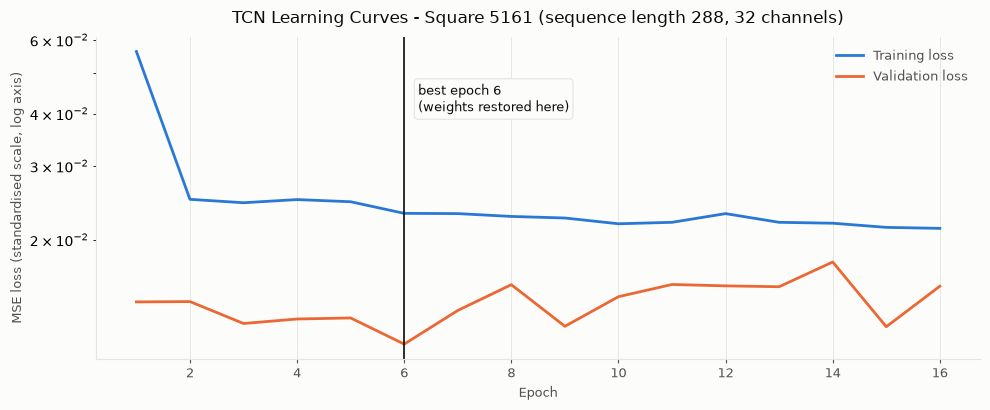

epochs run 16 | best epoch 6
train loss  first 0.05626  at best 0.02311  final 0.02127
valid loss  first 0.01420  at best 0.01126  final 0.01548
validation loss at the end is +37.5% versus its best


In [24]:
plot_learning_curves(RESULTS / "tcn_learning_curves.json",
                     "TCN Learning Curves",
                     "sequence length 288, 32 channels")

## 12. Final test results

The model configurations were selected on validation metrics. The final test metrics below were never used to choose or change any of them.

### 12.1 The three required tables

In [25]:
metrics = pd.read_csv(RESULTS / "final_model_metrics.csv")

for area in [5161, 5059, 5259]:
    table = (metrics[metrics.square_id == area]
             .sort_values("MAE")[["model", "MAE", "RMSE", "MAPE"]]
             .reset_index(drop=True).round(3))
    print("Square %d" % area)
    display(table)

Square 5161


,model,MAE,RMSE,MAPE
0,LSTM,86.380,127.082,9.754
1,AR (Selected-Lag),87.941,129.019,9.059
2,TCN,88.578,125.298,11.331


Square 5059


,model,MAE,RMSE,MAPE
0,LSTM,69.795,100.825,6.982
1,TCN,79.608,114.330,7.713
2,AR (Selected-Lag),91.563,127.527,9.266


Square 5259


,model,MAE,RMSE,MAPE
0,AR (Selected-Lag),65.802,92.376,7.610
1,TCN,66.890,96.314,7.621
2,LSTM,67.847,97.232,7.520


In [26]:
means = metrics.groupby("model")[["MAE", "RMSE", "MAPE"]].mean().round(3)
means = means.sort_values("MAE")
print("Mean across the three areas:")
display(means)

print("Best model per area and metric:")
winners = []
for area in [5161, 5059, 5259]:
    block = metrics[metrics.square_id == area]
    winners.append({"square_id": area,
                    "best MAE": block.loc[block.MAE.idxmin(), "model"],
                    "best RMSE": block.loc[block.RMSE.idxmin(), "model"],
                    "best MAPE": block.loc[block.MAPE.idxmin(), "model"]})
display(pd.DataFrame(winners))

Mean across the three areas:


,MAE,RMSE,MAPE
model,,,
LSTM,74.674,108.380,8.085
TCN,78.358,111.981,8.888
AR (Selected-Lag),81.769,116.307,8.645


Best model per area and metric:


,square_id,best MAE,best RMSE,best MAPE
0,5161,LSTM,TCN,AR (Selected-Lag)
1,5059,LSTM,LSTM,LSTM
2,5259,AR (Selected-Lag),AR (Selected-Lag),LSTM


The main result is that the **LSTM has the best mean MAE, RMSE and MAPE**.

No selected model is the best on every area and every metric though:

- **Square 5059 strongly favours the LSTM:** It wins all three metrics there. It also wins MAE by a wide margin, with 69.80 against 79.61 for the TCN and 91.56 for the AR model.
- **Square 5259 is won by the AR model on MAE and RMSE:** The simplest and cheapest of the three has the lowest MAE and RMSE on that area. The LSTM has the lowest MAPE there.
- **Square 5161 has a different winner depending on the metric:** The LSTM has the best MAE, the TCN has the best RMSE and the AR model has the best MAPE. The winner reported for this area would change if the metric had been chosen differently.

### 12.2 Forecast plots

Nine plots follow, grouped by area. The three plots inside each area share the same y-axis limits, so the models can be compared fairly by eye.

#### Square 5161

This is the busiest of the three areas, and it swings the most between the quiet hours of the night and the daytime peak.

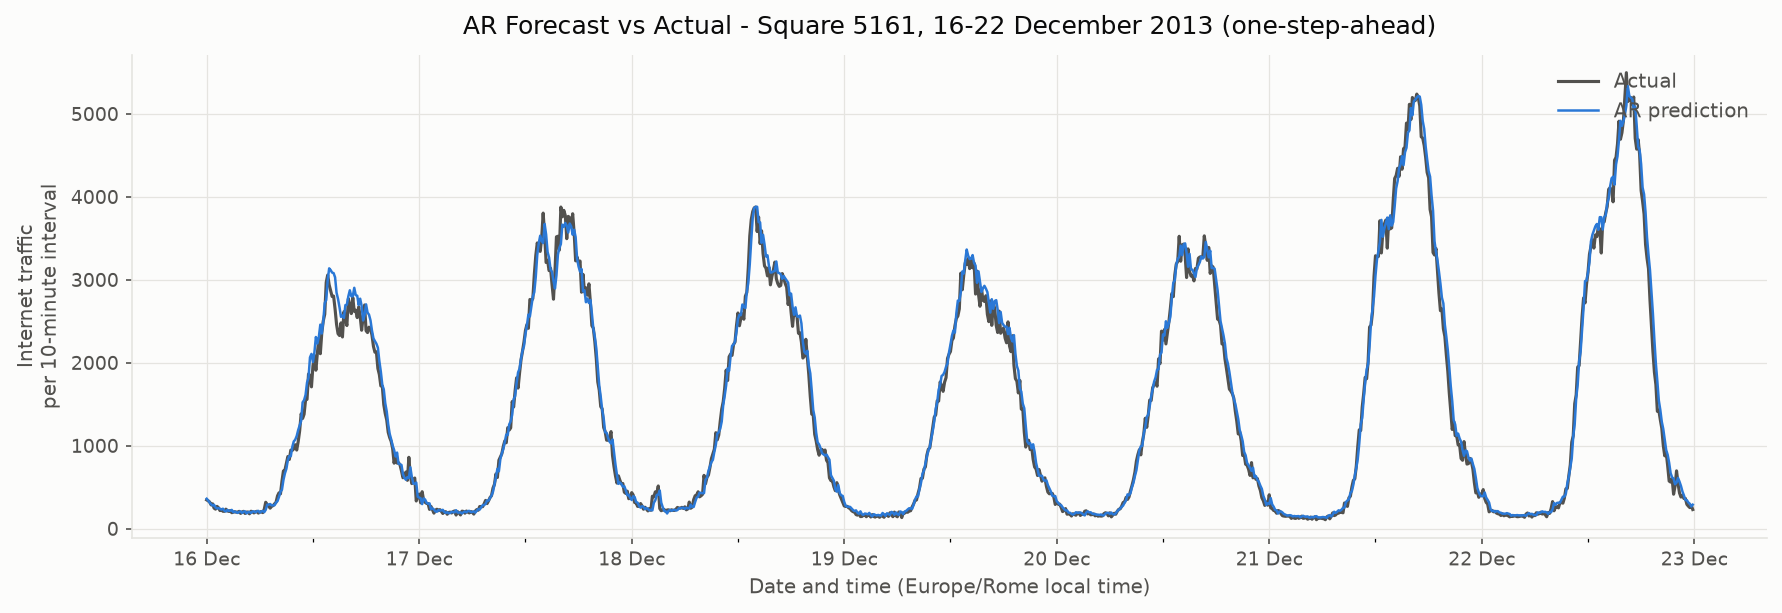

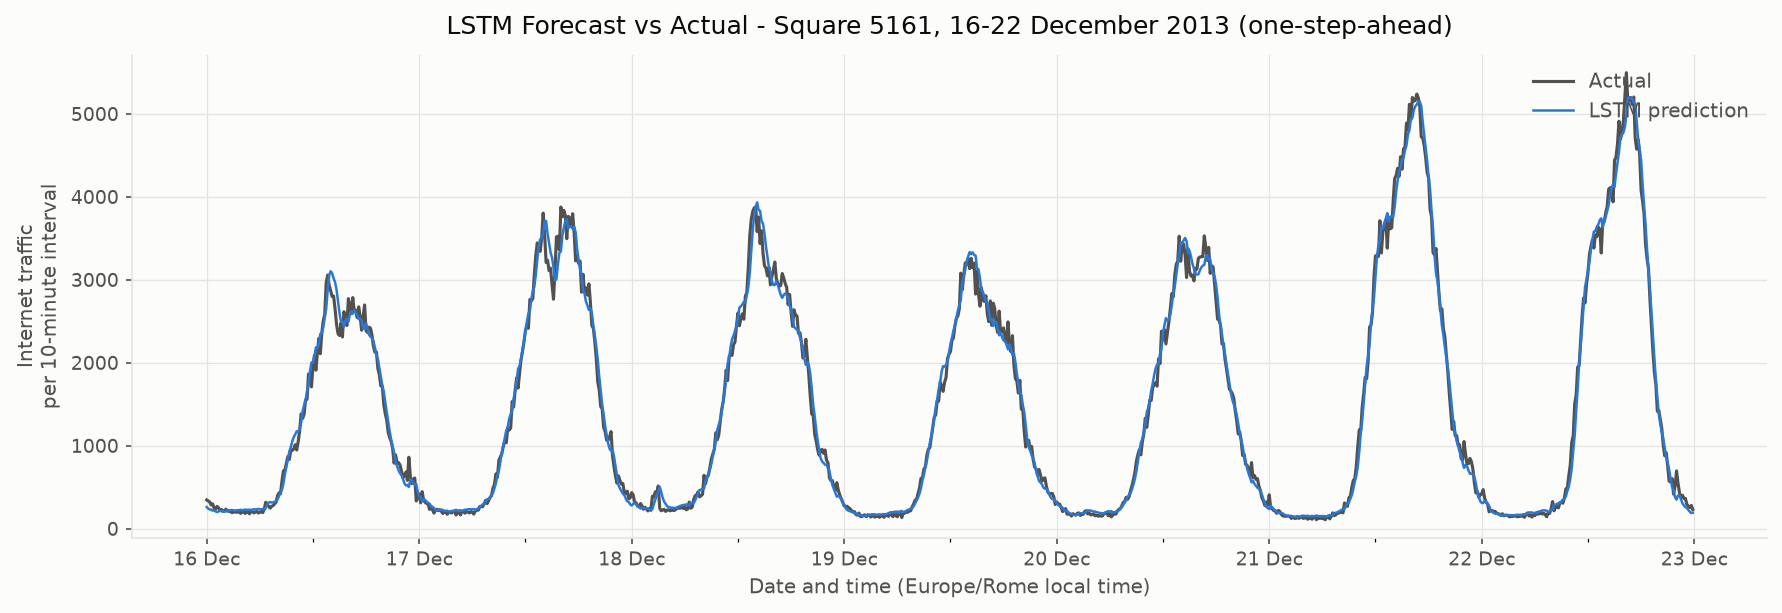

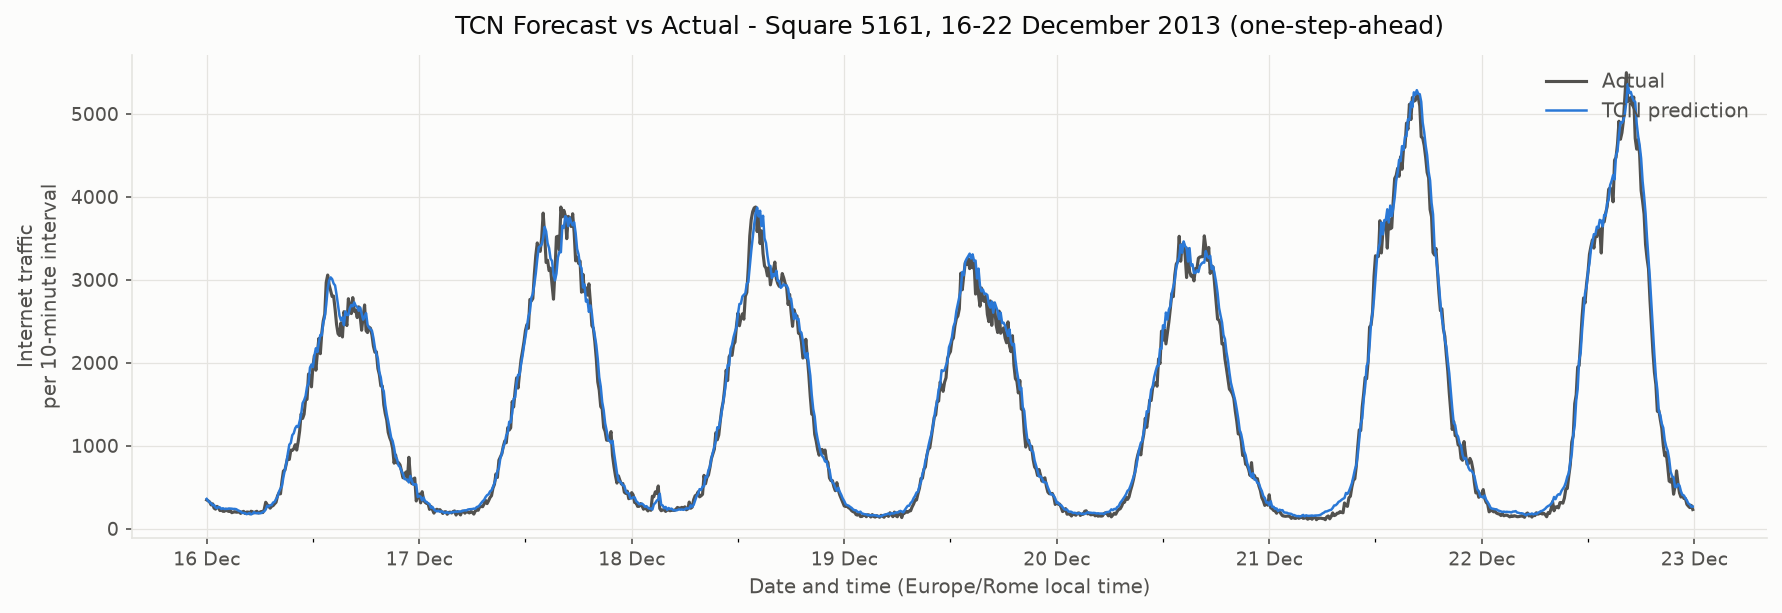

In [27]:
for model_name in ["ar", "lstm", "tcn"]:
    name = model_name + "_square_5161.png"
    display(Image(filename=str(FIGURES / "final_forecasts" / name)))

#### Square 5059

The traffic here is smoother than on Square 5161 and its daily shape is flatter.

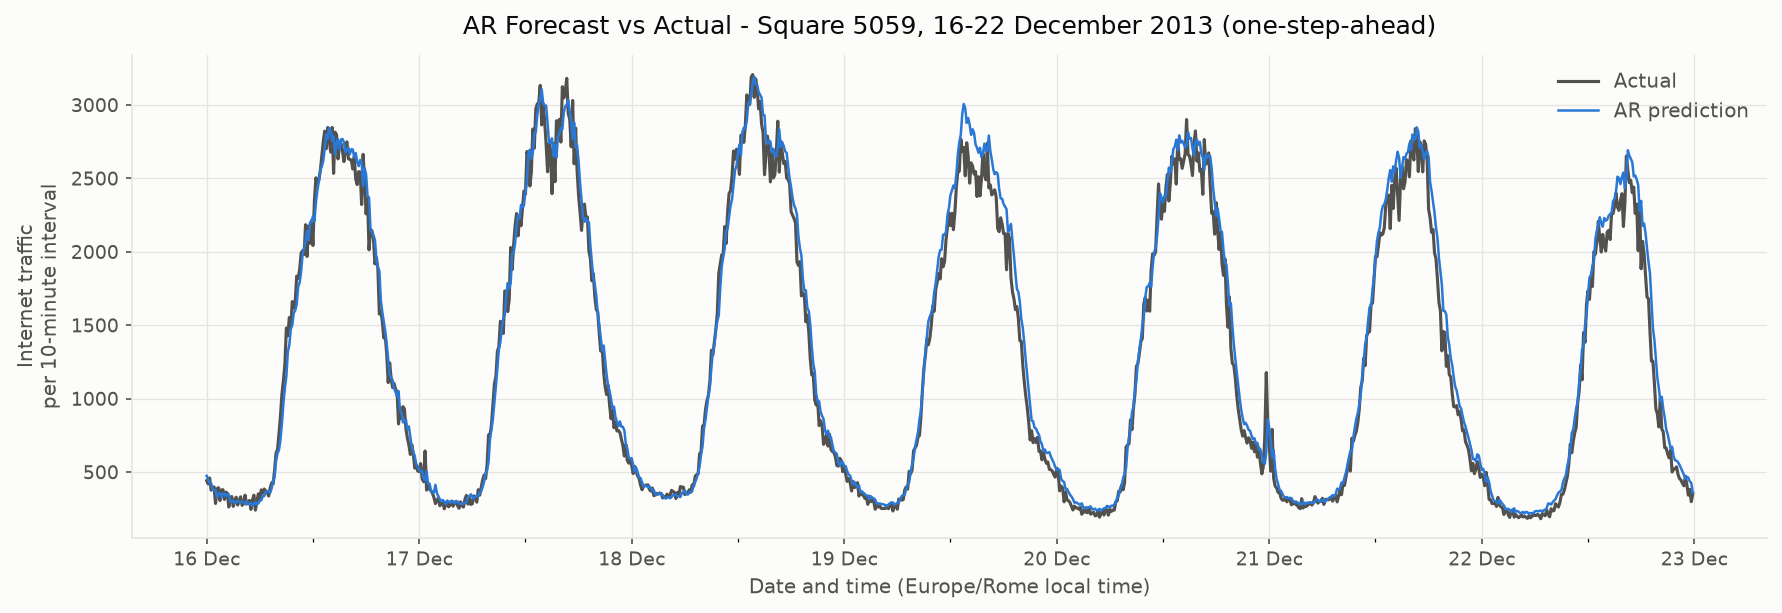

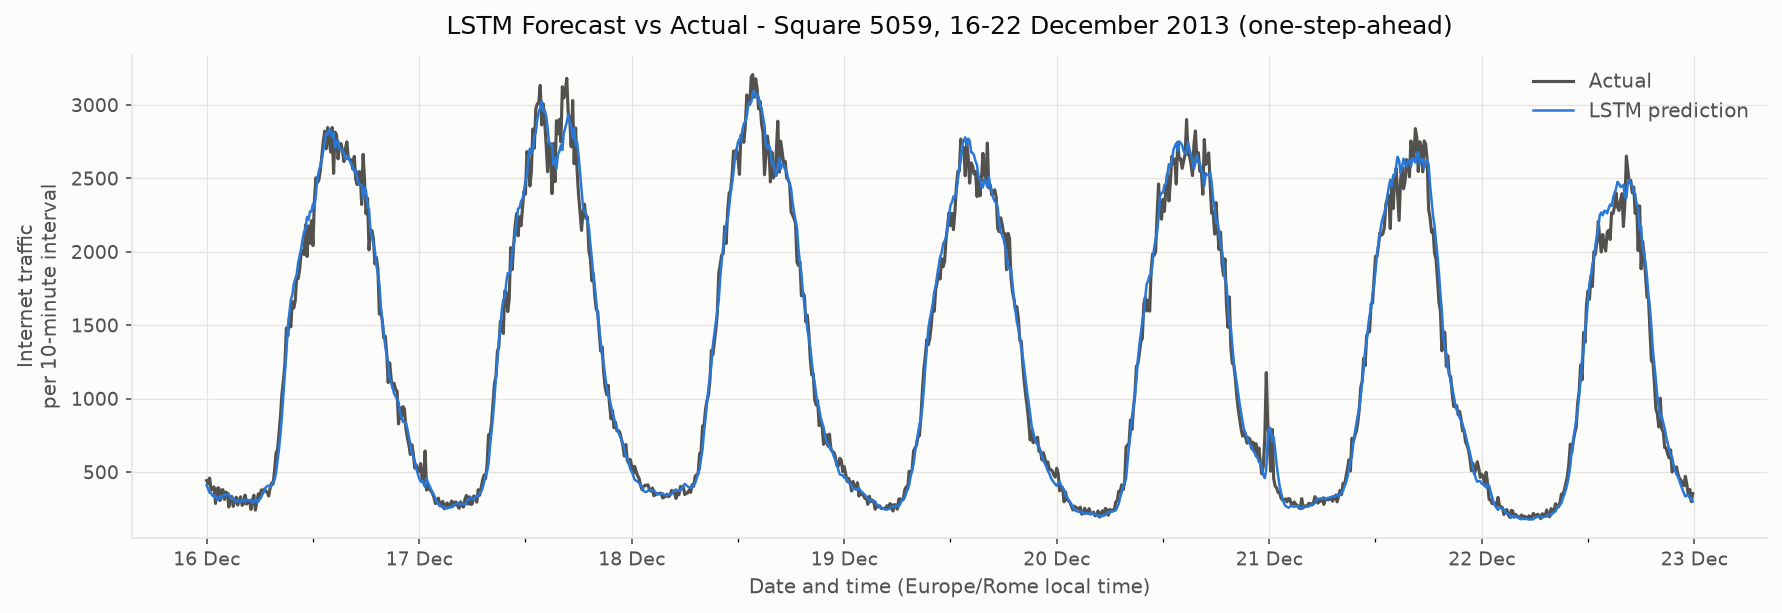

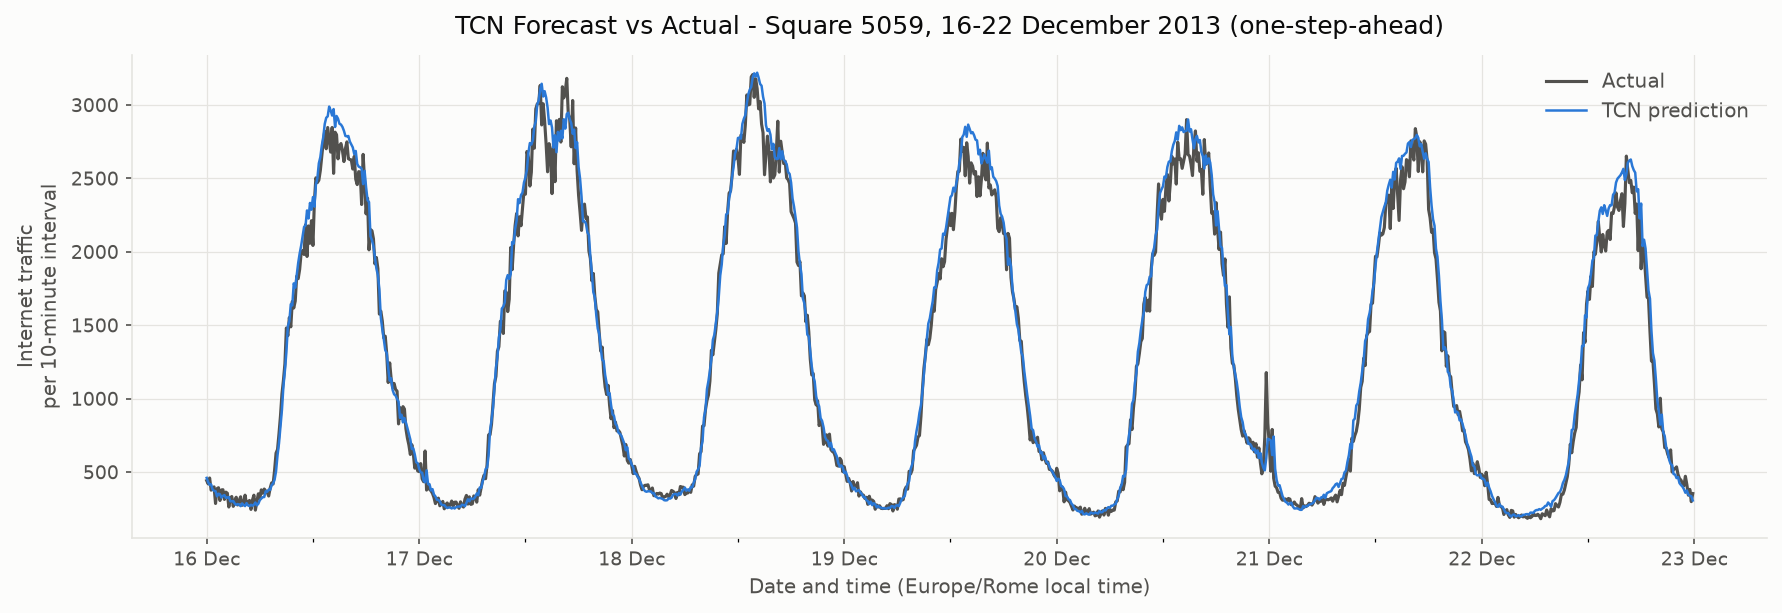

In [28]:
for model_name in ["ar", "lstm", "tcn"]:
    name = model_name + "_square_5059.png"
    display(Image(filename=str(FIGURES / "final_forecasts" / name)))

#### Square 5259

This area has the biggest gap between weekdays and weekends of the three. You can see it in the lower and flatter weekend days on the right side of each plot.

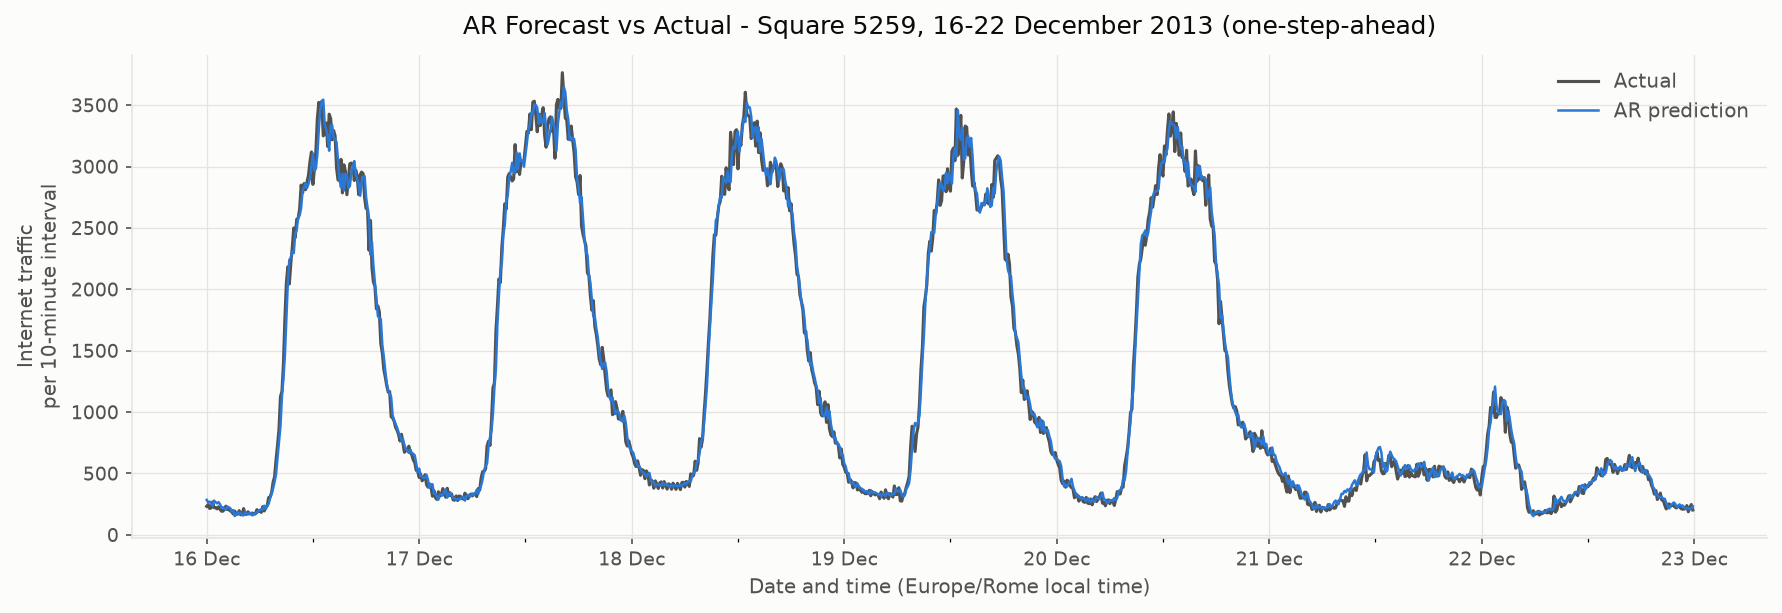

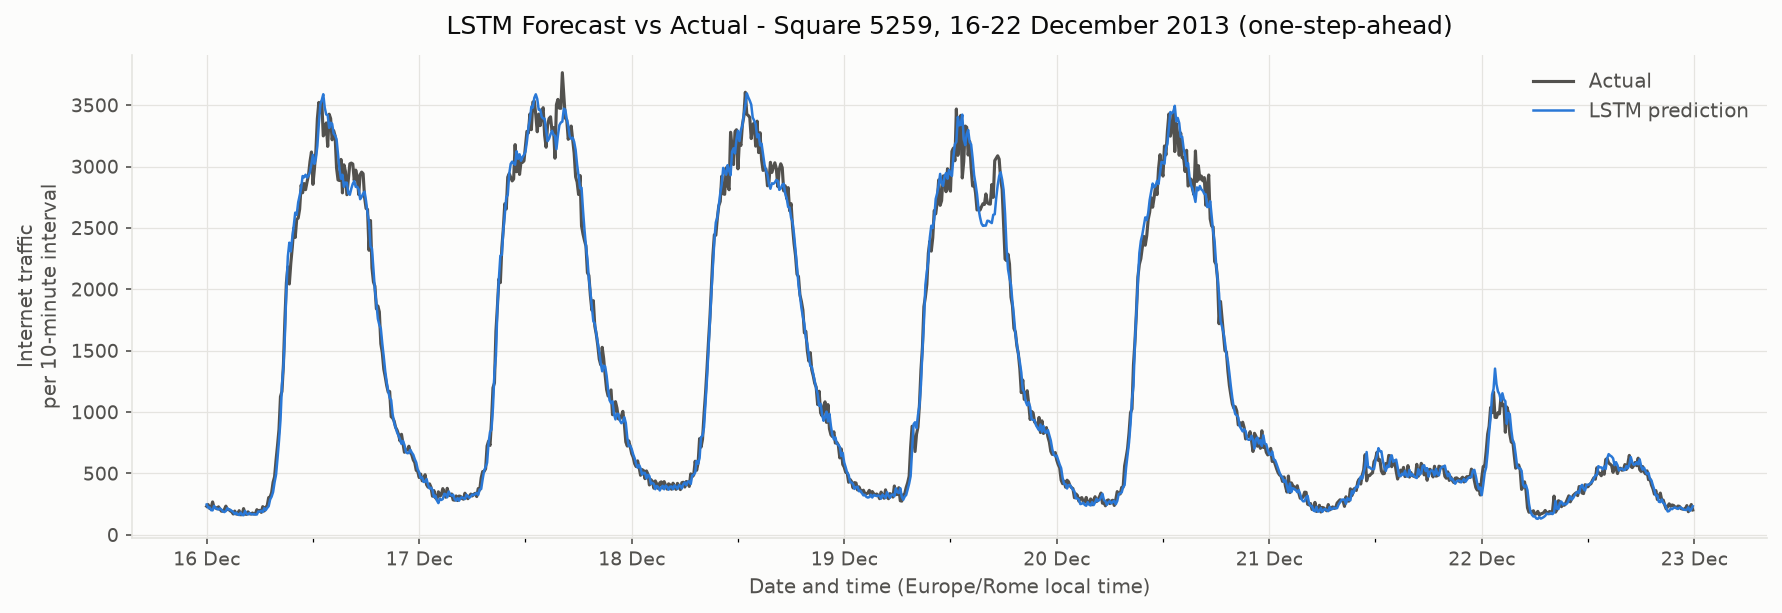

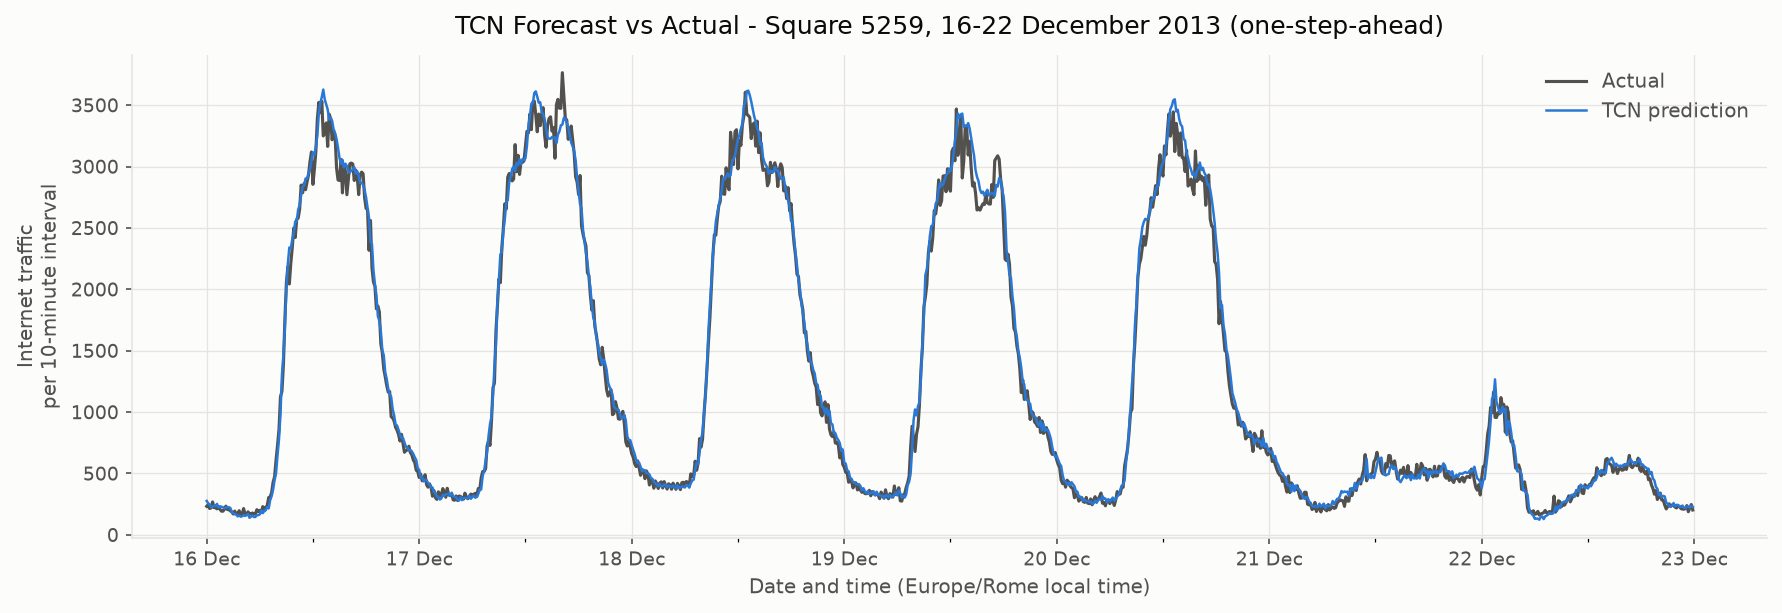

In [29]:
for model_name in ["ar", "lstm", "tcn"]:
    name = model_name + "_square_5259.png"
    display(Image(filename=str(FIGURES / "final_forecasts" / name)))

## 13. Failure analysis

An average error tells us how the models did overall, but it hides the situations where they struggled. In this section I break the test week errors down by traffic level, by how fast traffic was changing, and by the type of day. I then look closely at the single worst hour. What I want to find out is whether the three models fail in the same situations or in different ones. That says far more about how they differ than the average metrics do.

I went through the errors in a systematic way instead of looking at the plots and guessing.

### 13.1 Error by traffic level

In [30]:
diagnostics = pd.read_csv(RESULTS / "failure_analysis.csv")
diagnostics["timestamp"] = pd.to_datetime(diagnostics["timestamp"], utc=True).dt.tz_convert(TZ)

by_quartile = (diagnostics.groupby(["square_id", "model", "traffic_quartile"])
               .agg(MAE=("abs_error", "mean"), MAPE=("abs_pct_error", "mean"),
                    mean_actual=("actual", "mean"))
               .round(3).reset_index())
order = ["Q1 lowest", "Q2", "Q3", "Q4 highest"]
by_quartile["traffic_quartile"] = pd.Categorical(
    by_quartile["traffic_quartile"], categories=order, ordered=True)
display(by_quartile.pivot_table(index=["square_id", "model"],
                                columns="traffic_quartile",
                                values="MAPE", observed=False).round(3))

traffic_quartile  Q1 lowest      Q2     Q3  Q4 highest
square_id model                                       
5059      AR         11.417  11.554  8.970       5.122
          LSTM        8.275   9.422  6.172       4.058
          TCN        10.171   8.874  6.542       5.265
5161      AR         12.057  12.108  7.555       4.518
          LSTM       14.648  12.872  6.831       4.665
          TCN        20.227  13.436  7.377       4.284
5259      AR         11.492   8.576  6.660       3.713
          LSTM       10.499   8.761  6.721       4.100
          TCN        10.831   8.739  7.102       3.811

The percentage error tends to be larger when traffic is low, while the absolute error tends to be larger when traffic is high. There are exceptions in both directions, such as the AR model on Square 5059, which has a larger MAE in Q3 than in Q4.

Part of this comes from the measure itself rather than from the models. MAPE puts the actual value on the bottom of the fraction. The same mistake in traffic units therefore looks far bigger in percentage terms whenever traffic is small.

### 13.2 The TCN and low traffic on Square 5161

That general property does not explain everything, because all three models divide by the same value. The finding that belongs to one model alone is this. The TCN is especially weak next to the AR model and the LSTM in the lowest traffic quartile of Square 5161.

In [31]:
q1 = diagnostics[(diagnostics.square_id == 5161)
                 & (diagnostics.traffic_quartile == "Q1 lowest")]
all_5161 = diagnostics[diagnostics.square_id == 5161]

rows = []
for name in ["AR", "LSTM", "TCN"]:
    block = q1[q1.model == name]
    whole = all_5161[all_5161.model == name]
    rows.append({
        "model": name,
        "Q1 MAE": block.abs_error.mean(),
        "Q1 MAPE": block.abs_pct_error.mean(),
        "Q4 MAPE": all_5161[(all_5161.model == name)
                            & (all_5161.traffic_quartile == "Q4 highest")].abs_pct_error.mean(),
        "Q1 mean signed error": (block.prediction - block.actual).mean(),
        "share of total % error from Q1":
            100 * block.abs_pct_error.sum() / whole.abs_pct_error.sum(),
    })
display(pd.DataFrame(rows).round(3))

,model,Q1 MAE,Q1 MAPE,Q4 MAPE,Q1 mean signed error,share of total % error from Q1
0,AR,20.722,12.057,4.518,13.112,33.272
1,LSTM,25.319,14.648,4.665,20.918,37.543
2,TCN,34.295,20.227,4.284,29.827,44.627


The TCN's MAPE in the lowest quartile is 20.23 percent, against 12.06 for the AR model and 14.65 for the LSTM. About 44.6 percent of the TCN's total percentage error comes from that one quartile, even though it covers only 25 percent of the intervals. The TCN also over-forecasts there more than the other two, with a mean signed error of +29.83 against +20.92 and +13.11.

In the highest traffic quartile the TCN actually has the **best** MAPE of the three. This is therefore a specific weakness at low traffic, not a general one.

### 13.3 Error by rate of change and by day type

In [32]:
change_view = (diagnostics.groupby(["square_id", "model", "change_quartile"])
               ["abs_error"].mean().round(2).reset_index())
c_order = ["C1 smallest", "C2", "C3", "C4 largest"]
change_view["change_quartile"] = pd.Categorical(
    change_view["change_quartile"], categories=c_order, ordered=True)
print("MAE by quartile of absolute change from the previous observation:")
display(change_view.pivot_table(index=["square_id", "model"],
                               columns="change_quartile",
                               values="abs_error", observed=False))

day_view = diagnostics.groupby(["square_id", "model", "is_weekend"])["abs_error"].mean().unstack()
day_view.columns = ["weekday MAE", "weekend MAE"]
day_view["ratio"] = (day_view["weekend MAE"] / day_view["weekday MAE"])
print("Weekday against weekend:")
display(day_view.round(3))

MAE by quartile of absolute change from the previous observation:


change_quartile  C1 smallest     C2     C3  C4 largest
square_id model                                       
5059      AR           44.68  61.88  96.86      162.83
          LSTM         30.61  47.67  69.18      131.72
          TCN          39.93  57.12  83.33      138.05
5161      AR           31.19  44.38  90.52      185.68
          LSTM         41.23  53.03  88.04      163.21
          TCN          44.05  55.29  88.30      166.67
5259      AR           26.38  35.31  56.93      144.60
          LSTM         31.22  45.44  70.28      124.44
          TCN          36.82  44.92  62.60      123.22

Weekday against weekend:


weekday MAE  weekend MAE  ratio
square_id model                                 
5059      AR          89.572       96.540  1.078
          LSTM        70.231       68.704  0.978
          TCN         79.410       80.103  1.009
5161      AR          83.095      100.056  1.204
          LSTM        85.841       87.728  1.022
          TCN         84.105       99.759  1.186
5259      AR          74.798       43.311  0.579
          LSTM        76.990       44.991  0.584
          TCN         74.975       46.677  0.623

Across these three areas the absolute error generally grows in the intervals where traffic changed the most. On Square 5161 the AR model goes from an MAE of 31.19 in the calmest quartile to 185.68 in the most volatile one.

Square 5259 stands out once the errors are split by type of day. All three models have a lower weekend MAE there, with weekend to weekday ratios of around 0.58 to 0.62. On the other two areas the ratio sits close to 1, and traffic on Square 5259 is also much lower at weekends. Part of that smaller absolute error is therefore expected simply because the values are smaller, not because the models are relatively more accurate. This is the same area that had the biggest weekday to weekend contrast in the first two weeks.

### 13.4 The AR model on Square 5059

The AR model is much worse than the LSTM on Square 5059. I traced where that gap comes from, rather than guessing at it.

In [33]:
area_5059 = diagnostics[diagnostics.square_id == 5059]
ar = area_5059[area_5059.model == "AR"].reset_index(drop=True)
lstm = area_5059[area_5059.model == "LSTM"].reset_index(drop=True)

print("AR mean signed error   : %+.2f" % (ar.prediction - ar.actual).mean())
print("LSTM mean signed error : %+.2f" % (lstm.prediction - lstm.actual).mean())
print("(positive means over-forecasting)")
print()

gap = (ar.abs_error - lstm.abs_error).groupby(ar.hour).mean().round(2)
worst_hours = gap.sort_values(ascending=False).head(6)
print("Hours where the AR model loses most ground to the LSTM:")
display(worst_hours.rename("extra AR error").to_frame())

AR mean signed error   : +54.96
LSTM mean signed error : +9.69
(positive means over-forecasting)

Hours where the AR model loses most ground to the LSTM:


,extra AR error
hour,
19,90.98
20,77.86
18,60.68
17,43.53
21,39.70
22,32.28


The AR model keeps over-forecasting on this area, with a mean signed error of +54.96 against +9.69 for the LSTM. The extra error is concentrated in the evening, and the largest hourly gaps fall around 18:00 to 20:00, where the AR model is roughly 61 to 91 traffic units of MAE worse than the LSTM. Several neighbouring evening hours are raised as well.

That is a clear pattern that can be measured. No explanation is offered for why the evening behaves this way, because none was demonstrated.

### 13.5 The selected failure case

I chose the failure case by measured error, rather than by how the plots look. It is the single hour with the highest mean absolute error across all three models in the whole test week.

**Square 5161, 16 December 2013, 14:00 to 15:00 Milan local time.**

In [34]:
case_lo = pd.Timestamp("2013-12-16 14:00", tz=TZ)
case_hi = pd.Timestamp("2013-12-16 15:00", tz=TZ)

hour = predictions[(predictions.square_id == 5161)
                   & (predictions.timestamp >= case_lo)
                   & (predictions.timestamp < case_hi)].copy()
view = hour[["timestamp", "actual", "persistence", "ar_prediction",
             "lstm_prediction", "tcn_prediction"]].copy()
view["timestamp"] = view["timestamp"].dt.strftime("%H:%M")
view.columns = ["time", "actual", "persistence", "AR", "LSTM", "TCN"]
display(view.round(1).reset_index(drop=True))

# The size of the fall is printed, so the number is never negative.
print("Traffic fell %.1f%% across the hour, from %.1f to %.1f"
      % (100 * (hour.actual.iloc[0] - hour.actual.iloc[-1]) / hour.actual.iloc[0],
         hour.actual.iloc[0], hour.actual.iloc[-1]))
print()
summary = []
for column, name in [("persistence", "Persistence"), ("ar_prediction", "AR"),
                     ("lstm_prediction", "LSTM"), ("tcn_prediction", "TCN")]:
    error = hour[column] - hour["actual"]
    summary.append({"model": name, "MAE in the hour": error.abs().mean(),
                    "mean signed error": error.mean()})
display(pd.DataFrame(summary).round(2))

,time,actual,persistence,AR,LSTM,TCN
0,14:00,2866.1,2938.1,3117.2,3102.9,3028.9
1,14:10,2798.7,2866.1,3086.8,3077.2,3008.8
2,14:20,2803.1,2798.7,3080.4,3016.1,2955.6
3,14:30,2646.8,2803.1,3030.1,2971.0,2931.7
4,14:40,2462.7,2646.8,2843.8,2879.8,2821.1
5,14:50,2350.5,2462.7,2768.8,2740.7,2692.7


Traffic fell 18.0% across the hour, from 2866.1 to 2350.5



,model,MAE in the hour,mean signed error
0,Persistence,99.38,97.92
1,AR,333.19,333.19
2,LSTM,309.97,309.97
3,TCN,251.83,251.83


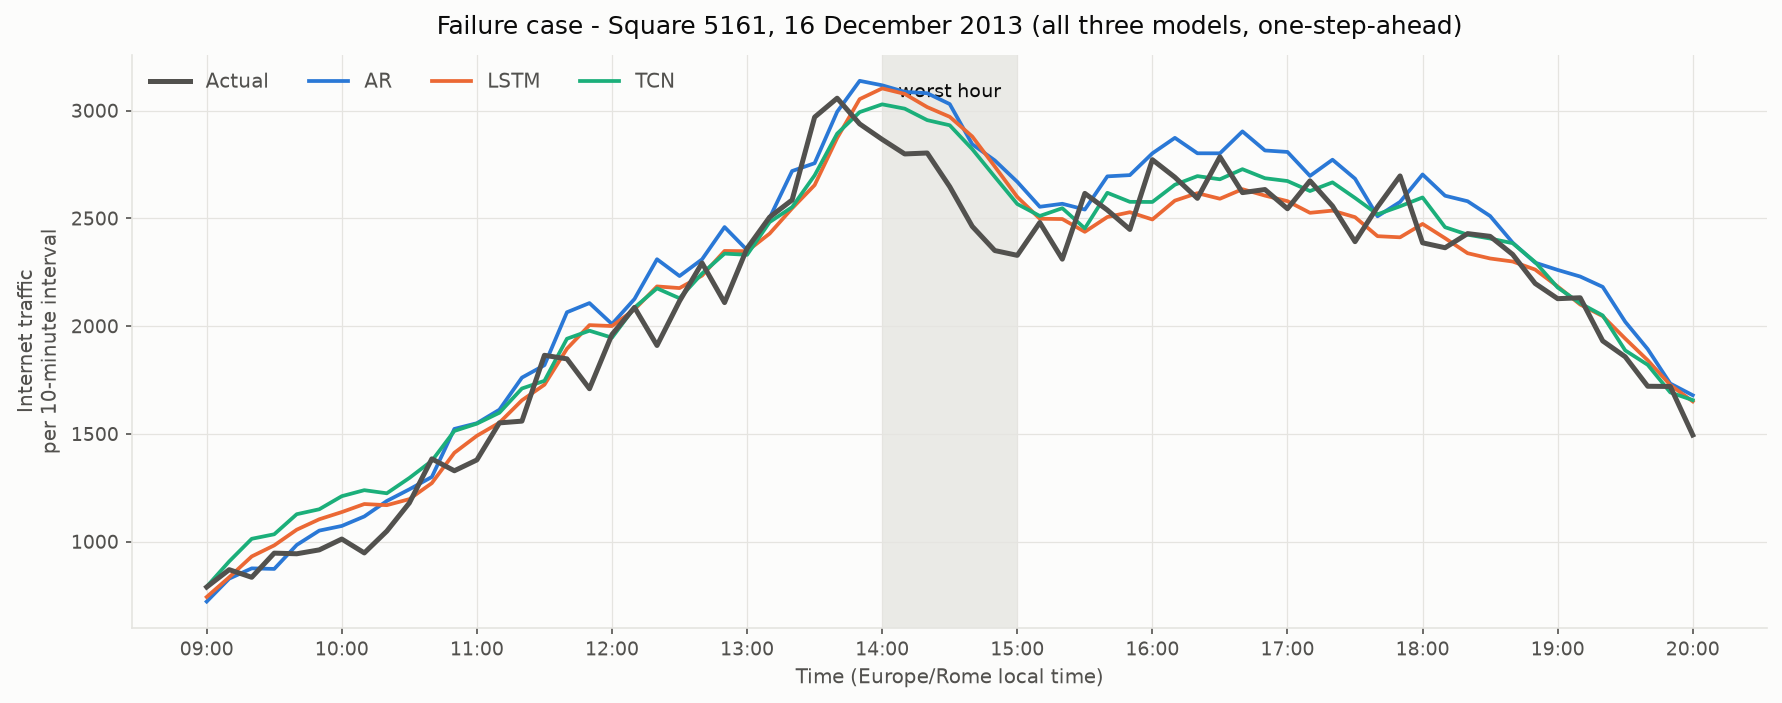

In [35]:
display(Image(filename=str(FIGURES / "failure_case.png")))

**What happened in the real traffic:** Traffic peaked shortly before the chosen hour, at about 3,057 at 13:40. It then fell by about 18 percent between 14:00 and 15:00, from about 2,866 at 14:00 down to about 2,350 at 14:50.

**Which models missed it:** All three missed it, and all of them missed in the same direction. Every signed error inside that hour is positive, so each model was forecasting too high the whole way through.

**How large the error was:** AR 333.19, LSTM 309.97 and TCN 251.83. For comparison, the AR model's MAE across the whole test week on this area is 87.94, so its worst hour is roughly 3.8 times its normal error level.

**What made the period difficult:** It sits right on a turning point. At 14:00 all three models predicted between 3,029 and 3,117, which is **above the last observed value of 2,938**. Every one of them was forecasting a rise while the series had already started to fall.

**What evidence supports that reading:** Persistence simply carries the last observation forward. It reached an MAE of 99.38 in the same hour, which is far below all three trained models. Persistence cannot project a direction, so it only lags behind the fall instead of forecasting against it. That fits with the trained models reacting too slowly to a rapid turning point. It is not proof that they were extrapolating a trend, and the real world cause of the drop in traffic is not known.

## 14. Cross-area comparison

There are only three forecasting areas here, so everything in this section is descriptive. No causal relationship is claimed, because three points could never support one.

In [36]:
# These numbers are recomputed with the helpers from section 4.
rows = []
for area in [5161, 5059, 5259]:
    block = metrics[metrics.square_id == area].set_index("model")
    chars = area_characteristics(area)
    rows.append({
        "square_id": area,
        "mean traffic": chars["mean"],
        "coefficient of variation": chars["coef_variation"],
        "peak-to-mean ratio": chars["peak_to_mean"],
        "first-two-week weekend/weekday traffic ratio":
            weekend_weekday_ratio(area),
        "AR MAE": block.loc["AR (Selected-Lag)", "MAE"],
        "LSTM MAE": block.loc["LSTM", "MAE"],
        "TCN MAE": block.loc["TCN", "MAE"],
    })
display(pd.DataFrame(rows).round(3))


,square_id,mean traffic,coefficient of variation,peak-to-mean ratio,first-two-week weekend/weekday traffic ratio,AR MAE,LSTM MAE,TCN MAE
0,5161,1426.978,0.968,5.637,1.290,87.941,86.380,88.578
1,5059,1251.216,0.768,3.729,0.754,91.563,69.795,79.608
2,5259,1174.482,0.939,3.782,0.314,65.802,67.847,66.890


The weekend to weekday ratio above is the **first-two-week weekend/weekday traffic ratio** measured in the exploratory stage. It is not a ratio over the full period, and not a ratio for the test week either.

Descriptive observations:

- Square 5161 has the highest coefficient of variation and by far the highest peak-to-mean ratio. All three models still land within about 2.2 MAE of each other there, so no model gains an edge on the most variable area.
- Square 5059 is the smoothest of the three, but it shows the **widest spread between models**, from 69.80 to 91.56. Being smooth did not make it easy for everyone, and it was in fact the hardest area for the AR model.
- Square 5259 has the lowest mean traffic and the lowest MAE for all three models, which again sit within about 2.0 MAE of each other.
- There is no clean ordering in which any single characteristic tells you which model is going to win.

### 14.1 Comparison against persistence

In [37]:
rows = []
for area in [5161, 5059, 5259]:
    block = predictions[predictions.square_id == area]
    actual = block["actual"]
    persistence_error = block["persistence"] - actual
    base_mae = persistence_error.abs().mean()
    base_mape = (persistence_error.abs() / actual).mean() * 100
    for column, name in [("ar_prediction", "AR"), ("lstm_prediction", "LSTM"),
                         ("tcn_prediction", "TCN")]:
        error = block[column] - actual
        rows.append({
            "square_id": area, "model": name,
            "MAE": error.abs().mean(),
            "persistence MAE": base_mae,
            "beats persistence on MAE": error.abs().mean() < base_mae,
            "MAPE": (error.abs() / actual).mean() * 100,
            "persistence MAPE": base_mape,
            "beats persistence on MAPE": (error.abs() / actual).mean() * 100 < base_mape,
        })
comparison = pd.DataFrame(rows)
display(comparison.round(3))

,square_id,model,MAE,persistence MAE,beats persistence on MAE,MAPE,persistence MAPE,beats persistence on MAPE
0,5161,AR,87.941,92.802,True,9.059,9.194,True
1,5161,LSTM,86.380,92.802,True,9.754,9.194,False
2,5161,TCN,88.578,92.802,True,11.331,9.194,False
3,5059,AR,91.563,81.517,False,9.266,7.959,False
4,5059,LSTM,69.795,81.517,True,6.982,7.959,True
5,5059,TCN,79.608,81.517,True,7.713,7.959,True
6,5259,AR,65.802,75.968,True,7.610,8.115,True
7,5259,LSTM,67.847,75.968,True,7.520,8.115,True
8,5259,TCN,66.890,75.968,True,7.621,8.115,True


This table has to be read carefully because the answer changes depending on which metric you look at.

- **By MAE both the LSTM and the TCN beat persistence on all three areas. The AR model loses to persistence on Square 5059.**
- **By MAPE the LSTM and the TCN are worse than persistence on Square 5161. The AR model is worse than persistence on Square 5059.**

So persistence is never beaten everywhere by any of the models. It stays a demanding benchmark, which fits with the very high lag 1 autocorrelation found in the exploratory analysis. It also fits with the wider forecasting literature, where simple benchmarks are known to be hard to beat [11].

## 15. Computational cost

### 15.1 Hardware and software

I used Square 5161 as the representative area for the timing, because it carries the most traffic of the three. Every model was run on the CPU only.

In [38]:
timing = pd.read_csv(RESULTS / "final_timing.csv")
environment = timing.iloc[0]

hardware = pd.DataFrame([
    {"item": "CPU", "value": "12th Gen Intel(R) Core(TM) i7-1255U"},
    {"item": "CPU cores", "value": "10 physical / 12 logical"},
    {"item": "Installed RAM", "value": "15.65 GB usable (16 GB installed)"},
    {"item": "Operating system", "value": "Microsoft Windows 11 Pro, build 26200"},
    {"item": "Python", "value": environment["python"]},
    {"item": "PyTorch", "value": environment["torch"]},
    {"item": "PyTorch CPU threads", "value": int(environment["torch_threads"])},
    {"item": "CUDA available", "value": bool(environment["cuda_available"])},
    {"item": "NumPy", "value": environment["numpy"]},
    {"item": "pandas", "value": environment["pandas"]},
])
display(hardware)

,item,value
0,CPU,12th Gen Intel(R) Core(TM) i7-1255U
1,CPU cores,10 physical / 12 logical
2,Installed RAM,15.65 GB usable (16 GB installed)
3,Operating system,"Microsoft Windows 11 Pro, build 26200"
4,Python,3.13.1
5,PyTorch,2.14.0+cpu
6,PyTorch CPU threads,10
7,CUDA available,False
8,NumPy,2.5.3
9,pandas,3.0.5


### 15.2 What the timers included

**Training timer:** For the AR model this covers the least squares solve alone, with the design matrix already built. For the LSTM and the TCN it covers creating the model, setting up the optimiser, the whole training loop with early stopping, and restoring the best weights. The tensors and the data loader are prepared beforehand. The timer leaves out reading the raw files, preprocessing, scaling, building the sequences, plotting and writing CSV files.

**Inference timer:** This covers 1,008 separate single step model calls after a warm up, which is how one-step-ahead forecasting would really be used. Preparing the sequences and the design matrix happens outside the timer.

The number reported is the **median** rather than the best of the runs.

In [39]:
train = timing[timing.phase == "training"][
    ["model", "median_s", "min_s", "max_s", "repetitions"]].round(6)
train.columns = ["model", "median (s)", "min (s)", "max (s)", "repetitions"]
print("Training time:")
display(train.reset_index(drop=True))

infer = timing[timing.phase == "inference_1008"].copy()
infer["per prediction (ms)"] = (infer["median_s"] / 1008 * 1000).round(4)
infer = infer[["model", "median_s", "min_s", "max_s", "per prediction (ms)",
               "repetitions"]].round(6)
infer.columns = ["model", "median for 1008 (s)", "min (s)", "max (s)",
                 "per prediction (ms)", "repetitions"]
print("Inference time for the complete 1,008 point forecast:")
display(infer.reset_index(drop=True))

Training time:


,model,median (s),min (s),max (s),repetitions
0,AR,0.002665,0.001799,0.008026,200
1,LSTM,72.261708,71.469822,78.818894,3
2,TCN,393.018676,388.705449,416.500600,3


Inference time for the complete 1,008 point forecast:


,model,median for 1008 (s),min (s),max (s),per prediction (ms),repetitions
0,AR,0.007481,0.006949,0.008452,0.0074,5
1,LSTM,1.639409,1.634071,1.719134,1.6264,5
2,TCN,14.044513,13.940507,14.140713,13.9330,5


The AR solve takes only a few milliseconds, so one measurement could be affected by timing noise. I repeated it 200 times and recorded a median of 0.002665 seconds and a minimum of 0.001799 seconds. For the LSTM and TCN, I measured three complete training runs each.

The absolute values are the important part:

- Training: AR 0.002665 s, LSTM 72.26 s, TCN 393.02 s.
- Producing all 1,008 forecasts: AR 0.007481 s, LSTM 1.6394 s, TCN 14.0445 s.

The ratios between these numbers are very large, but they should be quoted carefully. The AR time on the bottom of the fraction is so small that a few milliseconds of measurement noise moves the ratio a long way. The absolute figures are therefore the more meaningful ones. At a 10 minute resolution all three models are fast enough for a single area. The gap would matter a great deal more if the same work had to be done for all 10,000 squares.

## 16. Main findings

**1. Model performance varies by geographical area:** No selected model wins everywhere, because the LSTM clearly wins Square 5059 and takes Square 5161 on MAE, while the AR model wins Square 5259 on MAE and RMSE.

**2. The LSTM has the best mean predictive performance** with the lowest mean MAE, RMSE and MAPE across the three areas.

**3. The AR model is extremely cheap to run and still competitive:** It trains in under three milliseconds, and produces the forecast for the whole test week in about 7.5 milliseconds, using only 16 parameters. It has the lowest MAE and RMSE on Square 5259, where the LSTM has the lowest MAPE.

**4. The TCN gained more from a longer history than the tested LSTM did**, but its extra complexity did not beat the LSTM overall. The TCN improved clearly when its window went from 36 to 144 steps, while the LSTM did best with 36. Even then, the TCN comes only second by mean MAE and mean RMSE, and it holds the **worst mean MAPE of the three selected models**.

**5. More model complexity did not guarantee better results:** The TCN has 40,577 parameters, against 17,217 for the LSTM and 16 for the AR model. It is still not the most accurate model on any metric averaged across the areas.

**6. Persistence remains a difficult benchmark, and especially so when traffic changes quickly:** By MAE the LSTM and the TCN beat persistence on all three areas. The AR model beats it on Squares 5161 and 5259, but does worse on Square 5059. By MAPE the LSTM and the TCN lose to it on Square 5161. In the worst hour of the test week, persistence beat all three trained models by a wide margin.

**7. The choice of metric affects the ranking:** On Square 5161 the best model is the LSTM by MAE, the TCN by RMSE and the AR model by MAPE, so reporting only one metric would hide all of that.

**8. Looking at the failures shows things that an average MAE hides:** The TCN's weakness at low traffic on Square 5161 is invisible in a single averaged number, and so is the AR model's evening over-forecasting on Square 5059.

## 17. Limitations

**Only three areas are used for the official model comparison:** Squares 5161, 5059 and 5259 were selected because they carry the most traffic. Three areas cannot support a general claim about all 10,000 squares.

**The exploratory analysis used the whole 62-day series:** The autocorrelation, the seasonal decomposition and the stationarity work in sections 4 and 5 were all computed on the full period. That period includes the official 16 to 22 December evaluation week and the later unused stretch, and this work also helped shape the candidate lag and history window choices. The final choices among the tested configurations were still made on validation metrics, and the final test metrics were never used to choose or change them. The 16 to 22 December week should therefore be read as the assignment's official evaluation window, rather than a completely untouched holdout. No model was fitted on test data.

**The three areas were chosen using the whole dataset:** They were picked as the busiest by total Internet traffic summed over all 62 days, which includes the validation and test weeks. The step of choosing areas is therefore not a conventional untouched holdout. The model selection that follows for each area still uses validation metrics only.

**The three models do not receive the same history:** The AR model is handed selected daily and weekly lags, so week-old information reaches it directly. The LSTM reads 36 contiguous observations, which is six hours, while the TCN reads 288 contiguous observations, which is two days. I gave each family the window that won on validation, so this compares the models as configured rather than three architectures on identical inputs.

**The models only look at one area at a time:** Each model sees nothing but the past of its own square. It never uses the traffic of neighbouring squares, even though published work on this dataset shows that nearby cells depend on each other [4], [5]. That information was deliberately left outside the scope here.

**Only one fixed test week is evaluated:** All the test results come from 16 to 22 December 2013, so a different week could give a different ranking, and no confidence interval over several test periods is computed.

**The hyperparameter search is deliberately small and controlled:** Three sequence lengths and two widths were tested for each neural model, changing one factor at a time. This keeps the comparison easy to read, but it also means the search does not find the best possible configuration for any of the three models.

**No outside information is included:** Calendar effects, public holidays, events and weather are never used as inputs. That is true even though the exploratory analysis showed that 1 November behaved unusually.

**Two of the selection decisions rest on weak evidence:** The LSTM's 64 hidden units beat 32 by about 0.3 percent. The TCN's 288 step window beat 144 by about 0.1 percent. Both were decided by the rule declared in advance, but neither margin is convincing.

**The last ten days of the data behave differently from the rest**, and they are not in any of the splits. Traffic in that period drops well below the earlier level, so the conclusions here do not cover the late-December and early-January stretch. No holiday effect is established for that segment, and only the change in level is observed.

## 18. Reproducibility and references

### 18.1 Script order

| Step | Script | What it does |
|---|---|---|
| 1 | `scripts/download_data.py` | Downloads and verifies all 62 telecom files |
| 2 | `scripts/prepare_data.py` | Aggregates 319,896,289 raw rows and builds the selected-area series |
| 3 | `scripts/ar_model.py` | Baselines and the autoregressive experiments |
| 4 | `scripts/lstm_model.py` | LSTM experiments and the frozen LSTM |
| 5 | `scripts/tcn_model.py` | TCN experiments and the frozen TCN |
| 6 | `scripts/evaluate_models.py` | Regenerates predictions, forecast figures and the failure analysis |
| 7 | `scripts/benchmark_models.py` | The representative timing benchmark |

Only steps 1 and 2 need the raw data, because everything from step 3 onwards works from the small processed files. The exploratory and time series analysis in sections 4 and 5 of this notebook is worked out here directly.

In [40]:
recorded = log[log.evaluated_on == "test"]
pairs = {"ar_prediction": "AR-FINAL", "lstm_prediction": "LSTM-FINAL",
         "tcn_prediction": "TCN-FINAL"}

rows = []
for column, experiment in pairs.items():
    for area in [5161, 5059, 5259]:
        block = predictions[predictions.square_id == area]
        error = block[column] - block["actual"]
        mae = error.abs().mean()
        reference = recorded[(recorded.experiment_id == experiment)
                             & (recorded.area == area)].iloc[0]
        rows.append({"model": experiment, "square_id": area,
                     "MAE recomputed": mae, "MAE recorded": reference.MAE,
                     "difference": mae - reference.MAE})
check = pd.DataFrame(rows)
display(check.round(6))

worst = check["difference"].abs().max()
ar_only = check[check.model == "AR-FINAL"]["difference"].abs().max()
print("largest difference recomputing from the saved CSV : %.3e" % worst)
print("largest difference for the AR model alone         : %.3e" % ar_only)

,model,square_id,MAE recomputed,MAE recorded,difference
0,AR-FINAL,5161,87.940926,87.940926,0.000000
1,AR-FINAL,5059,91.563113,91.563113,0.000000
2,AR-FINAL,5259,65.802112,65.802112,0.000000
3,LSTM-FINAL,5161,86.379765,86.379766,-0.000001
4,LSTM-FINAL,5059,69.795159,69.795157,0.000001
5,LSTM-FINAL,5259,67.847362,67.847362,-0.000001
6,TCN-FINAL,5161,88.577553,88.577553,-0.000000
7,TCN-FINAL,5059,79.607614,79.607613,0.000001
8,TCN-FINAL,5259,66.890113,66.890113,0.000000


largest difference recomputing from the saved CSV : 1.453e-06
largest difference for the AR model alone         : 2.842e-14


### 18.2 Numerical reproduction

The frozen metrics reproduced down to floating point noise, and the check that matters most is the one inside `scripts/evaluate_models.py`, which compares freshly computed predictions against the recorded metrics without ever writing them out to text first. Its worst difference across all the models, areas and metrics was **5.684e-14**, which is far below the 1e-9 tolerance.

The recomputation above works from the saved CSV instead, and it agrees to about 1e-6. That difference comes from the file rather than from the models. The neural network predictions start life as float32, so the CSV keeps only about 8 significant digits. The AR result reproduces to floating point precision, because its predictions stay float64 the whole way through. The largest AR difference in the recomputation above is about 2.84e-14 for one area.

No rerun was chosen because it gave a better result.

### 18.3 References

The sources cited in this notebook, with DOIs checked against Crossref, arXiv or DataCite, are:

[1] G. Barlacchi *et al.*, "A multi-source dataset of urban life in the city of
Milan and the Province of Trentino," *Scientific Data*, vol. 2,
Art. no. 150055, 2015.

[2] G. L. Santos *et al.*, "Predicting short-term mobile Internet traffic from
Internet activity using recurrent neural networks," *International Journal of
Network Management*, vol. 32, no. 3, Art. no. e2191, 2022.

[3] A. Azari, P. Papapetrou, S. Denic, and G. Peters, "Cellular traffic
prediction and classification: A comparative evaluation of LSTM and ARIMA," in
*Discovery Science*, 2019, pp. 129-144.

[4] C. Zhang and P. Patras, "Long-term mobile traffic forecasting using deep
spatio-temporal neural networks," in *Proc. ACM MobiHoc*, 2018, pp. 231-240.

[5] X. Wang *et al.*, "Spatio-temporal analysis and prediction of cellular
traffic in metropolis," *IEEE Transactions on Mobile Computing*, vol. 18,
no. 9, pp. 2190-2202, 2019.

[6] S. Hochreiter and J. Schmidhuber, "Long short-term memory," *Neural
Computation*, vol. 9, no. 8, pp. 1735-1780, 1997.

[7] Y. Bengio, P. Simard, and P. Frasconi, "Learning long-term dependencies
with gradient descent is difficult," *IEEE Transactions on Neural Networks*,
vol. 5, no. 2, pp. 157-166, 1994.

[8] J. Chung, C. Gulcehre, K. Cho, and Y. Bengio, "Empirical evaluation of
gated recurrent neural networks on sequence modeling," *arXiv:1412.3555*, 2014.

[9] S. Bai, J. Z. Kolter, and V. Koltun, "An empirical evaluation of generic
convolutional and recurrent networks for sequence modeling,"
*arXiv:1803.01271*, 2018.

[10] A. Zeng, M. Chen, L. Zhang, and Q. Xu, "Are Transformers effective for
time series forecasting?," in *Proc. AAAI*, vol. 37, no. 9, 2023,
pp. 11121-11128.

[11] S. Makridakis, E. Spiliotis, and V. Assimakopoulos, "The M4 Competition:
100,000 time series and 61 forecasting methods," *International Journal of
Forecasting*, vol. 36, no. 1, pp. 54-74, 2020.

[12] R. B. Cleveland, W. S. Cleveland, J. E. McRae, and I. Terpenning, "STL: A
seasonal-trend decomposition procedure based on loess," *Journal of Official
Statistics*, vol. 6, no. 1, pp. 3-73, 1990.

[13] X. Wang, K. Smith, and R. Hyndman, "Characteristic-based clustering for
time series data," *Data Mining and Knowledge Discovery*, vol. 13, no. 3,
pp. 335-364, 2006.

[14] R. J. Hyndman and G. Athanasopoulos, *Forecasting: Principles and
Practice*, 3rd ed. Melbourne, Australia: OTexts, 2021.

[15] G. E. P. Box, G. M. Jenkins, G. C. Reinsel, and G. M. Ljung, *Time Series
Analysis: Forecasting and Control*, 5th ed. Hoboken, NJ, USA: Wiley, 2015.